In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

# import kmapper as km
# import pyballmapper as pbm

import statistics
import warnings
warnings.filterwarnings('ignore')
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import ListedColormap
from matplotlib import colormaps as cm

In [9]:
data =pd.read_excel("/content/drive/MyDrive/Colab Notebooks/TDA/Data/TDA_ward_data.xlsx")
data.head(5)

,Ward_Name_x,Ward_Code,Total_Residents_16_Plus_Number_x,Qualification_No_Number,Qualification_No_Percentage,Qualification_Level_1_Number,Qualification_Level_1_Percentage,Qualification_Level_2_Number,Qualification_Level_2_Percentage,Qualification_Apprenticeship_Number,...,Aged.20.to.24.years,Aged.25.to.34.years,Aged.35.to.49.years,Aged.50.to.64.years,Aged.65.to.74.years,Aged.75.to.84.years,Aged.85.years.and.over,numin2021,meanyear2021,numberofschools
0,Astley Bridge,E05000650,11398,1999,17.5,1171,10.3,1749,15.3,703,...,688,1591,2734,2973,1398,943,401,2143.2,213624.2275,4.0
1,Bradshaw,E05000651,9455,1599,16.9,924,9.8,1197,12.7,724,...,455,1121,1942,2285,1549,1204,387,1244.2,241205.7804,4.0
2,Breightmet,E05000652,11218,2903,25.9,1327,11.8,1704,15.2,872,...,687,1736,2734,2741,1474,865,308,3880.6,145276.8456,13.0
3,Bromley Cross,E05000653,11347,1368,12.1,928,8.2,1519,13.4,739,...,591,1360,2540,3087,1729,1139,326,1955.9,244162.8148,4.0
4,Crompton (Bolton),E05000654,13336,3658,27.4,1539,11.5,1860,13.9,627,...,1205,2868,3666,2794,1178,548,202,5029.6,119025.3444,3.0


In [10]:
# Missing value
data[data['numberofschools'].isnull()]
data['numberofschools'].fillna(0, inplace=True)

In [11]:
null_columns=data.isnull().any()
null_columns.value_counts()

,count
False,267
True,4


In [12]:
null_columns[null_columns==True]

,0
Allotments Or Community Growing Spaces,True
Play Space,True
Public Park Or Garden,True
meanyear2021,True


In [13]:
data.columns

Index(['Ward_Name_x', 'Ward_Code', 'Total_Residents_16_Plus_Number_x',
       'Qualification_No_Number', 'Qualification_No_Percentage',
       'Qualification_Level_1_Number', 'Qualification_Level_1_Percentage',
       'Qualification_Level_2_Number', 'Qualification_Level_2_Percentage',
       'Qualification_Apprenticeship_Number',
       ...
       'Aged.20.to.24.years', 'Aged.25.to.34.years', 'Aged.35.to.49.years',
       'Aged.50.to.64.years', 'Aged.65.to.74.years', 'Aged.75.to.84.years',
       'Aged.85.years.and.over', 'numin2021', 'meanyear2021',
       'numberofschools'],
      dtype='object', length=271)

# <0. Map>

In [14]:
import geopandas as gpd

shape = gpd.read_file("/content/drive/MyDrive/Colab Notebooks/TDA/GroupData/WD_DEC_2022_UK_BFC.shp")

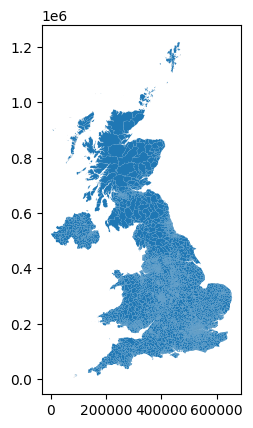

In [15]:
shape.plot(); plt.show()

In [16]:
print(shape.columns)

Index(['WD22CD', 'WD22NM', 'WD22NMW', 'LAD22CD', 'LAD22NM', 'BNG_E', 'BNG_N',
       'LONG', 'LAT', 'GlobalID', 'geometry'],
      dtype='object')


In [17]:
shape.head(1)

,WD22CD,WD22NM,WD22NMW,LAD22CD,LAD22NM,BNG_E,BNG_N,LONG,LAT,GlobalID,geometry
0,E05000650,Astley Bridge,None,E08000001,Bolton,370670,412906,-2.44479,53.6119,fb9555e0-fe42-4ed7-9525-83d2ef94b123,"POLYGON ((370294.199 414678.699, 370300.399 41..."


In [18]:
shape = shape.rename(columns={'WD22CD': 'Ward_Code'})
results = shape.merge(data, on='Ward_Code')

In [19]:
results.shape

(297, 281)

### 297 Wardcode Shape Mapping

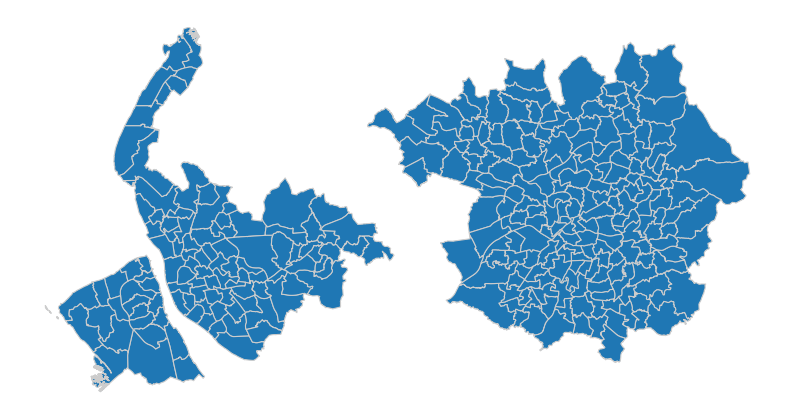

In [20]:
fig, ax = plt.subplots(1, figsize=(10, 8))
ax.axis('off')
divider = make_axes_locatable(ax)
results.plot(linewidth=0.8, ax=ax, edgecolor='0.8')
plt.show()

# <1. Individual Variable Analysis>

### 0. Target (Qualification)
**New variable**
* Higher Education:	level4 +
* Below Higher Education: Under level3
* Etc: otherq

In [21]:
qualification_columns = results.filter(regex='Qualification.*Percentage')

qualification_columns.columns

Index(['Qualification_No_Percentage', 'Qualification_Level_1_Percentage',
       'Qualification_Level_2_Percentage',
       'Qualification_Apprenticeship_Percentage',
       'Qualification_Level_3_Percentage',
       'Qualification_Level_4_Or_Above_Percentage',
       'Qualification_Other_Percentage'],
      dtype='object')

In [22]:
# import matplotlib.pyplot as plt

# plt.rcParams['figure.dpi'] = 150
# plt.rcParams['savefig.dpi'] = 150

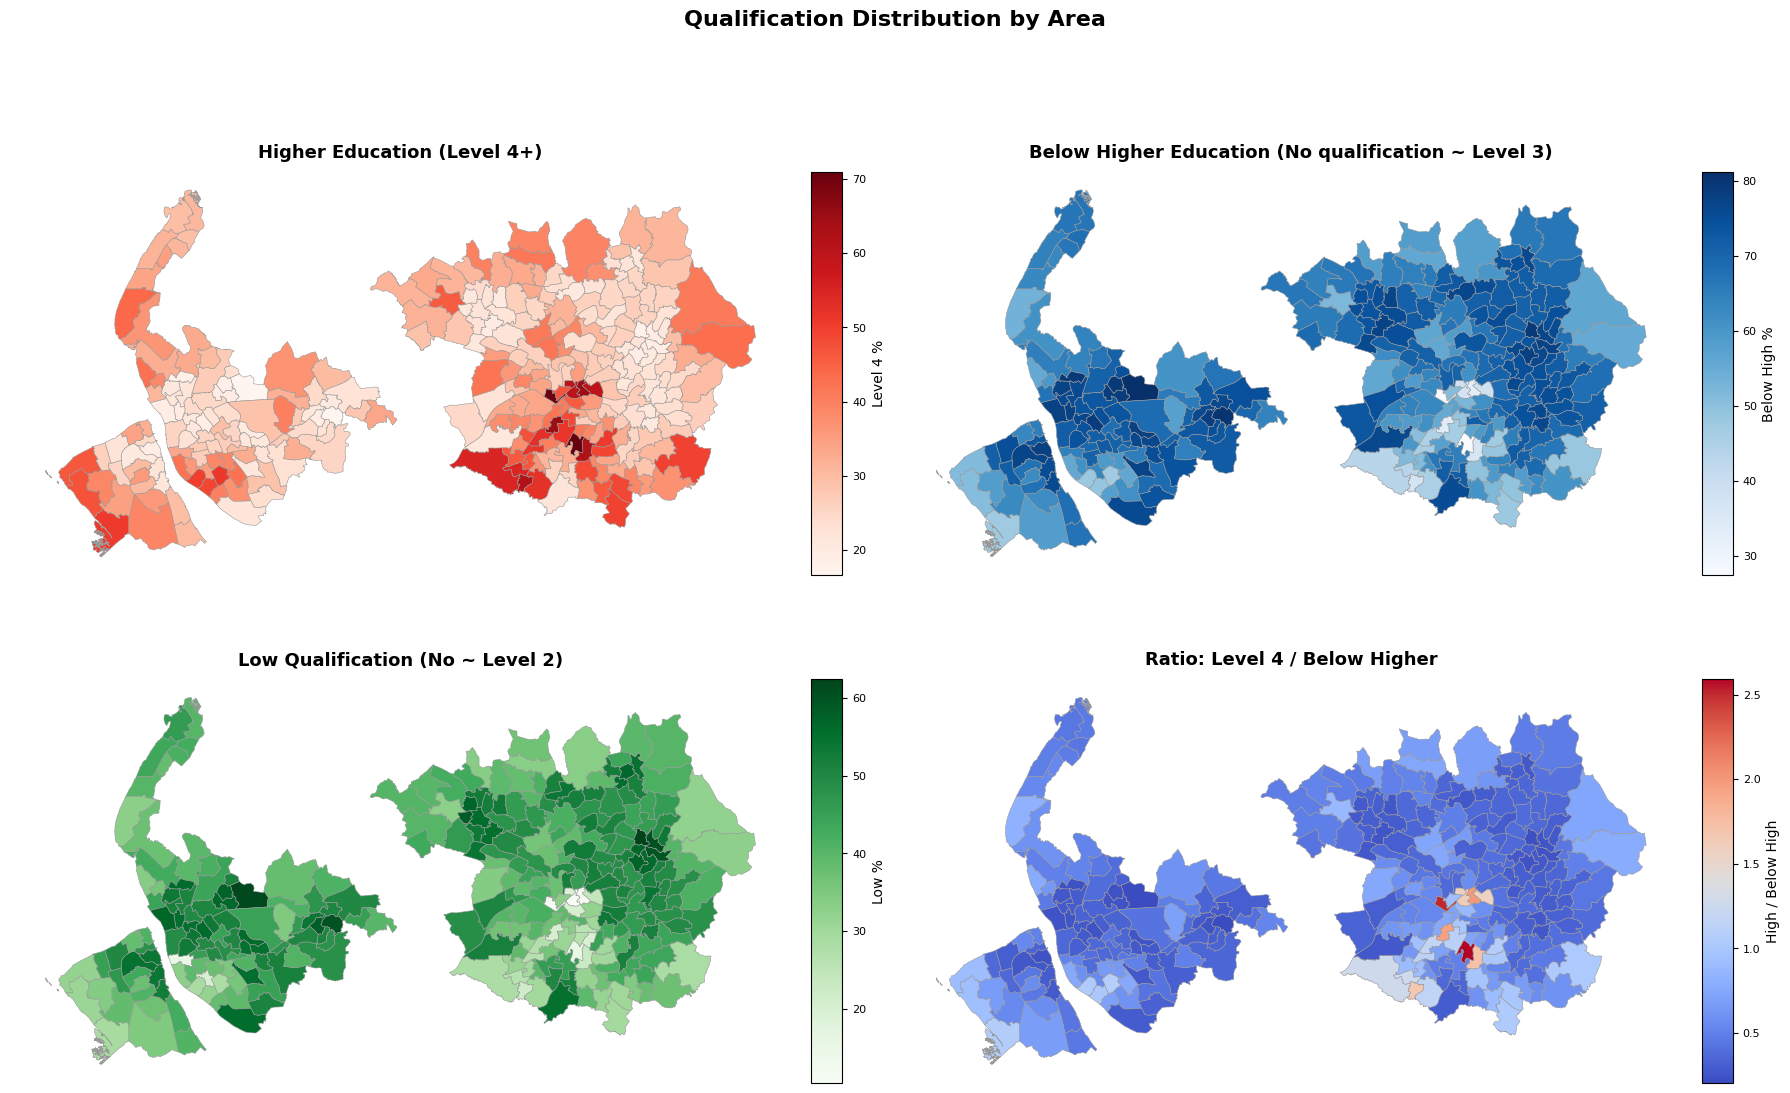

In [23]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib as mpl

high = results['Qualification_Level_4_Or_Above_Percentage']
below_high = results[['Qualification_No_Percentage', 'Qualification_Level_1_Percentage',
                      'Qualification_Level_2_Percentage', 'Qualification_Apprenticeship_Percentage',
                      'Qualification_Level_3_Percentage']].sum(axis=1)
low = results[['Qualification_No_Percentage', 'Qualification_Level_1_Percentage',
               'Qualification_Level_2_Percentage']].sum(axis=1)
ratio = high / below_high

results['high_value'] = high
results['below_high_value'] = below_high
results['low_value'] = low
results['ratio'] = ratio


fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

cmap_list = ['Reds', 'Blues', 'Greens', 'coolwarm']
titles = [
    'Higher Education (Level 4+)',
    'Below Higher Education (No qualification ~ Level 3)',
    'Low Qualification (No ~ Level 2)',
    'Ratio: Level 4 / Below Higher'
]
columns = ['high_value', 'below_high_value', 'low_value', 'ratio']
colorbars = ['Level 4 %', 'Below High %', 'Low %', 'High / Below High']


for i, ax in enumerate(axes):
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="4%", pad=0.2)
    ax.axis('off')

    plot = results.plot(column=columns[i], cmap=cmap_list[i], linewidth=0.4,
                        ax=ax, edgecolor='0.6', legend=False)

    sm = plt.cm.ScalarMappable(cmap=cmap_list[i],
        norm=plt.Normalize(vmin=results[columns[i]].min(), vmax=results[columns[i]].max()))
    sm._A = []
    cbar = plt.colorbar(sm, cax=cax)
    cbar.ax.tick_params(labelsize=8)
    cbar.set_label(colorbars[i], fontsize=10)

    ax.set_title(titles[i], fontsize=13, fontweight='bold', pad=10)

plt.suptitle("Qualification Distribution by Area", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [24]:
!pip install kmapper
!pip install pyballmapper

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.8/126.8 kB 4.6 MB/s eta 0:00:00


### 1. General Health

In [25]:
health_columns = results.filter(regex='Health.*Percentage|Percentage.*Health')
health_columns.columns

Index(['Health_Very_Good_Percentage', 'Health_Good_Percentage',
       'Health_Fair_Percentage', 'Health_Bad_Percentage',
       'Health_Very_Bad_Percentage'],
      dtype='object')

In [26]:
results['goodhealthp'] = results[['Health_Very_Good_Percentage', 'Health_Good_Percentage']].sum(axis=1)
results['goodhealthp'].head(3)

,goodhealthp
0,82.2
1,80.8
2,76.7


### 2. Disability

In [27]:
disability_columns = results.filter(regex='Disab.*Percentage|Percentage.*Disab')
disability_columns.columns

Index(['Disability_Equality_Act_Percentage',
       'Disability_Limited_A_Lot_Percentage',
       'Disability_Limited_A_Little_Percentage',
       'Not_Disabled_Equality_Act_Percentage',
       'Not_Disabled_Long_Term_Condition_Percentage',
       'Not_Disabled_No_Condition_Percentage'],
      dtype='object')

In [28]:
results[['Disability_Equality_Act_Percentage','Not_Disabled_Equality_Act_Percentage']].describe()

,Disability_Equality_Act_Percentage,Not_Disabled_Equality_Act_Percentage
count,297.000000,297.000000
mean,19.598316,80.401684
std,3.600961,3.600961
min,10.200000,70.500000
25%,17.300000,78.500000
50%,19.400000,80.600000
75%,21.500000,82.700000
max,29.500000,89.800000


count    297.000000
mean      19.598316
std        3.600961
min       10.200000
25%       17.300000
50%       19.400000
75%       21.500000
max       29.500000
Name: Disability_Equality_Act_Percentage, dtype: float64


<Axes: xlabel='Disability_Equality_Act_Percentage', ylabel='Count'>

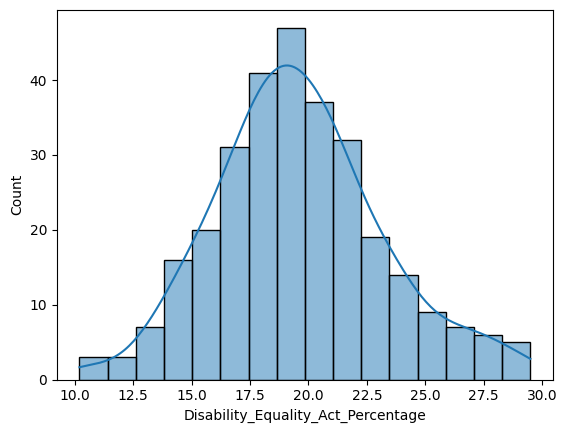

In [29]:
# Disability analysis
print(results['Disability_Equality_Act_Percentage'].describe())
sns.histplot(results['Disability_Equality_Act_Percentage'], kde=True)

In [30]:
results['disabledp'] = results['Not_Disabled_Equality_Act_Percentage']
results['disabledp'].head(1)

,disabledp
0,82.7


### 3. Deprivation

In [31]:
zqualification_columns = results.filter(like='Deprived', axis=1).filter(like='Percentage', axis=1)
qualification_columns.columns

Index(['Qualification_No_Percentage', 'Qualification_Level_1_Percentage',
       'Qualification_Level_2_Percentage',
       'Qualification_Apprenticeship_Percentage',
       'Qualification_Level_3_Percentage',
       'Qualification_Level_4_Or_Above_Percentage',
       'Qualification_Other_Percentage'],
      dtype='object')

### Target: High Qualification

In [32]:
results[['Household_Not_Deprived_Percentage','Household_Deprived_One_Dimension_Percentage',
         'Household_Deprived_Two_Dimensions_Percentage', 'Household_Deprived_Three_Dimensions_Percentage',
         'Household_Deprived_Four_Dimensions_Percentage']].describe()

,Household_Not_Deprived_Percentage,Household_Deprived_One_Dimension_Percentage,Household_Deprived_Two_Dimensions_Percentage,Household_Deprived_Three_Dimensions_Percentage,Household_Deprived_Four_Dimensions_Percentage
count,297.000000,297.000000,297.000000,297.000000,297.000000
mean,45.215152,33.126263,16.291246,5.105724,0.261953
std,8.816838,2.194369,4.613793,2.672634,0.190838
min,23.500000,24.100000,4.300000,0.700000,0.000000
25%,38.600000,32.000000,13.000000,3.000000,0.100000
50%,44.900000,33.400000,16.100000,4.700000,0.200000
75%,51.000000,34.500000,19.900000,6.800000,0.400000
max,70.300000,37.900000,27.900000,12.700000,0.900000


In [33]:
results['Deprived0p'] = results['Household_Not_Deprived_Percentage']
results['Deprived1p'] = results['Household_Deprived_One_Dimension_Percentage']
results['Deprived24p'] = results[['Household_Deprived_Two_Dimensions_Percentage', 'Household_Deprived_Three_Dimensions_Percentage',
                                  'Household_Deprived_Four_Dimensions_Percentage']].sum(axis=1)

print(results[['Deprived0p', 'Deprived1p', 'Deprived24p']].mean())

Deprived0p     45.215152
Deprived1p     33.126263
Deprived24p    21.658923
dtype: float64


### 4. Tenure

In [34]:
tenure_columns = results.filter(regex='Own|Rent', axis=1).filter(like='Percentage', axis=1)
tenure_columns.columns

Index(['Owned_Percentage', 'Owned_Outright_Percentage',
       'Owned_Mortgage_Percentage', 'Shared_Ownership_Percentage',
       'Shared_Ownership_Detail_Percentage', 'Social_Rented_Percentage',
       'Social_Rented_Council_Percentage', 'Social_Rented_Other_Percentage',
       'Private_Rented_Percentage', 'Private_Rented_Landlord_Percentage',
       'Private_Rented_Other_Percentage', 'Lives_Rent_Free_Percentage',
       'Owns_Mortgage_Shared_Ownership_Percentage',
       'Private_Rented_Lives_Free_Percentage'],
      dtype='object')

In [35]:
results['tenureownp'] = results['Owned_Percentage']
results['socrentp'] = results['Social_Rented_Percentage']
results['privrentp'] = results['Private_Rented_Percentage']

results[['tenureownp', 'socrentp', 'privrentp']].describe()

,tenureownp,socrentp,privrentp
count,297.000000,297.000000,297.000000
mean,59.186195,20.092256,19.952525
std,18.029871,12.182302,11.061853
min,14.500000,1.600000,6.200000
25%,47.000000,10.000000,12.900000
50%,61.700000,17.900000,16.800000
75%,73.500000,27.400000,23.400000
max,90.700000,55.800000,78.400000


### 5. Economic activity status

In [36]:
economicactivity_columns = results.filter(regex='Economic|Employe|employ', axis=1).filter(like='Percentage', axis=1)
economicactivity_columns.columns

Index(['Economically_Active_Percentage', 'Employee_Percentage',
       'Employee_Part_Time_Percentage', 'Employee_Full_Time_Percentage',
       'Self_Employed_With_Employees_Percentage',
       'Self_Employed_With_Employees_Part_Time_Percentage',
       'Self_Employed_With_Employees_Full_Time_Percentage',
       'Self_Employed_Without_Employees_Percentage',
       'Self_Employed_Without_Employees_Part_Time_Percentage',
       'Self_Employed_Without_Employees_Full_Time_Percentage',
       'Unemployed_Percentage',
       'Economically_Active_Full_Time_Student_Percentage',
       'Full_Time_Student_Employed_Percentage',
       'Full_Time_Student_Employee_Percentage',
       'Full_Time_Student_Employee_Part_Time_Percentage',
       'Full_Time_Student_Employee_Full_Time_Percentage',
       'Full_Time_Student_Self_Employed_With_Employees_Percentage',
       'Full_Time_Student_Self_Employed_With_Employees_Part_Time_Percentage',
       'Full_Time_Student_Self_Employed_With_Employees_Full_Time_

In [37]:
results[['Employee_Full_Time_Percentage','Employee_Part_Time_Percentage',
         'Self_Employed_With_Employees_Percentage', 'Self_Employed_Without_Employees_Percentage',
         'Unemployed_Percentage',
         'Economically_Inactive_Looking_After_Home_Percentage',
         'Economically_Inactive_Long_Term_Sick_Percentage']].describe()

,Employee_Full_Time_Percentage,Employee_Part_Time_Percentage,Self_Employed_With_Employees_Percentage,Self_Employed_Without_Employees_Percentage,Unemployed_Percentage,Economically_Inactive_Looking_After_Home_Percentage,Economically_Inactive_Long_Term_Sick_Percentage
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,33.939731,11.885522,1.315152,6.369360,3.081145,5.105724,5.788889
std,5.939114,1.723572,0.499330,1.150369,1.060269,2.604881,2.574454
min,17.400000,4.000000,0.400000,2.600000,1.200000,1.000000,0.600000
25%,30.900000,11.200000,1.000000,5.600000,2.300000,3.300000,3.900000
50%,34.200000,12.000000,1.200000,6.300000,3.000000,4.400000,5.400000
75%,37.500000,12.800000,1.500000,7.000000,3.900000,6.100000,7.300000
max,60.700000,21.800000,4.100000,10.400000,6.700000,15.600000,13.700000


In [38]:
results['employeep'] = results['Employee_Percentage']

# print(results['Employee_Percentage']) == print(results[['Employee_Full_Time_Percentage','Employee_Part_Time_Percentage']].sum(axis=1))

results['selfemployeep'] = results[['Self_Employed_With_Employees_Percentage','Self_Employed_Without_Employees_Percentage']].sum(axis=1)

results['nonemployedp'] = results[['Unemployed_Percentage','Economically_Inactive_Percentage']].sum(axis=1)

results[['employeep', 'selfemployeep', 'nonemployedp']].describe()

,employeep,selfemployeep,nonemployedp
count,297.000000,297.000000,297.000000
mean,45.821549,7.684512,44.078114
std,5.867945,1.563270,5.534812
min,22.400000,3.000000,19.200000
25%,43.300000,6.600000,40.800000
50%,46.500000,7.500000,43.900000
75%,49.400000,8.500000,47.200000
max,66.600000,14.000000,58.100000


### 6. Ethnic Group

In [39]:
ethinics_columns = results.filter(regex='Black|White|Asian|Other|Mixed', axis=1).filter(like='Percentage', axis=1)
ethinics_columns.columns

Index(['Qualification_Other_Percentage', 'Social_Rented_Other_Percentage',
       'Private_Rented_Other_Percentage',
       'Economically_Inactive_Other_Percentage', 'Asian_Total_Percentage',
       'Black_Total_Percentage', 'Mixed_Total_Percentage',
       'White_Total_Percentage', 'Other_Total_Percentage'],
      dtype='object')

In [40]:
results['ethnwhitep'] = results['White_Total_Percentage']
results['ethnotherp'] = results[['Asian_Total_Percentage','Black_Total_Percentage', 'Mixed_Total_Percentage', 'Other_Total_Percentage']].sum(axis=1)

results[['ethnwhitep', 'ethnotherp']].describe()

,ethnwhitep,ethnotherp
count,297.000000,297.000000
mean,82.243098,17.760943
std,17.903026,17.899410
min,16.500000,1.900000
25%,77.100000,5.300000
50%,89.100000,10.900000
75%,94.800000,22.900000
max,98.200000,83.400000


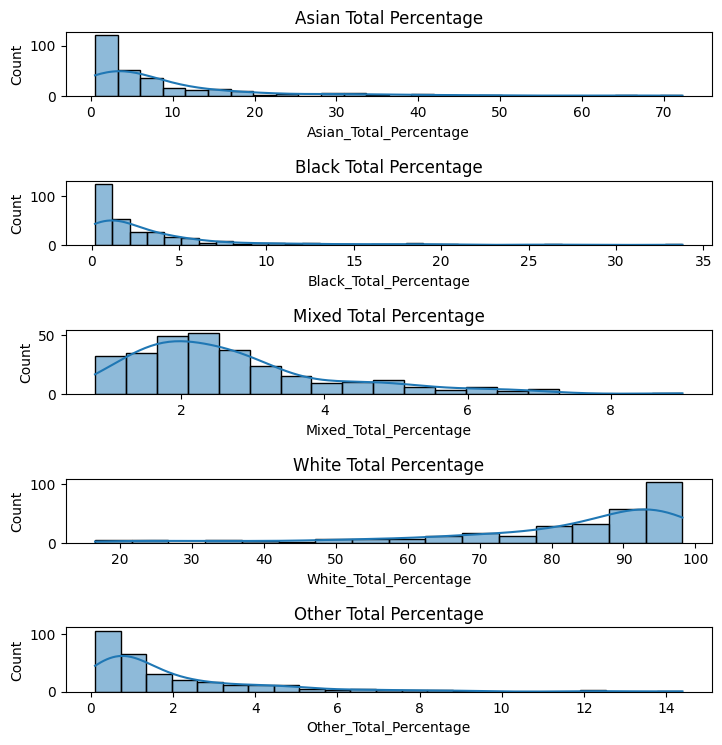

In [41]:
ethnic_columns = ['Asian_Total_Percentage','Black_Total_Percentage',
                  'Mixed_Total_Percentage','White_Total_Percentage','Other_Total_Percentage']

fig, axes = plt.subplots(5, 1, figsize=(8, 8))
fig.tight_layout(pad=4)

for i, col in enumerate(ethnic_columns):
    sns.histplot(results[col], kde=True, ax=axes[i])
    axes[i].set_title(col.replace('_', ' '))

plt.show()


### 7. NS-SeC

1. Higher Professional / Managerial
L1, L2, L3
➡ Higher_Managerial_Professional
2. Lower Professional / Intermediate
L4, L5, L6, L7
➡ Lower_Managerial_Intermediate
3. Self-Employed / Small Business
L8, L9
➡ Small_Employers_Self_Employed
4. Working Class / Routine Labor
L10, L11, L12, L13
➡ Routine_Working_Class
5. Inactive / Marginal
L14.1, L14.2, L15
➡ Unemployed_Non_Working

In [42]:
NSSeC_columns = results.filter(regex='Routine|Manage|Supervisory|Students|Occupations|Worked|Small', axis=1).filter(like='Percentage', axis=1)
NSSeC_columns.columns

Index(['Higher_Management_Percentage', 'Lower_Management_Percentage',
       'Intermediate_Occupations_Percentage', 'Small_Employers_Percentage',
       'Lower_Supervisory_Percentage', 'Semi_Routine_Percentage',
       'Routine_Percentage', 'Never_Worked_Unemployed_Percentage',
       'Full_Time_Students_Percentage', 'Managers_Directors_Percentage',
       'Professional_Occupations_Percentage',
       'Elementary_Occupations_Percentage'],
      dtype='object')

In [43]:
results[['Higher_Management_Percentage',
         'Lower_Management_Percentage','Intermediate_Occupations_Percentage',
         'Small_Employers_Percentage','Lower_Supervisory_Percentage',
         'Semi_Routine_Percentage','Routine_Percentage',
         'Never_Worked_Unemployed_Percentage','Full_Time_Students_Percentage']]

results['nssec1'] = results['Higher_Management_Percentage']
results['nssec2'] = results[['Lower_Management_Percentage','Intermediate_Occupations_Percentage']].sum(axis=1)
results['nssec3'] = results[['Small_Employers_Percentage','Lower_Supervisory_Percentage']].sum(axis=1)
results['nssec4'] = results[['Semi_Routine_Percentage','Routine_Percentage']].sum(axis=1)
results['nssec5'] = results[['Never_Worked_Unemployed_Percentage','Full_Time_Students_Percentage']].sum(axis=1)

In [44]:
nsc_df = results[['nssec1', 'nssec2', 'nssec3', 'nssec4', 'nssec5']]
results[['nssec1', 'nssec2', 'nssec3', 'nssec4', 'nssec5']].describe()

,nssec1,nssec2,nssec3,nssec4,nssec5
count,297.000000,297.000000,297.000000,297.000000,297.000000
mean,11.061953,31.319529,13.970370,24.612458,19.042424
std,5.927974,6.631754,2.029411,7.034530,9.212702
min,2.600000,12.600000,4.100000,5.300000,8.900000
25%,6.700000,26.800000,13.200000,19.800000,13.200000
50%,9.600000,32.300000,14.400000,25.400000,15.900000
75%,13.900000,36.500000,15.200000,30.100000,21.800000
max,33.100000,42.900000,17.200000,41.100000,68.100000


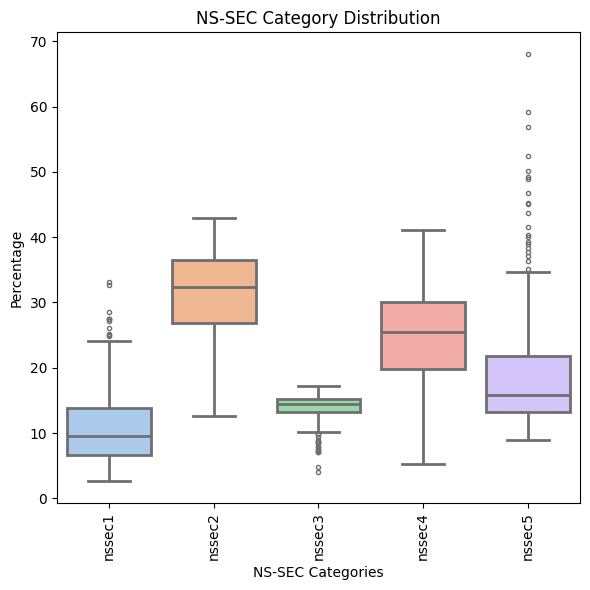

In [45]:
plt.figure(figsize=(6, 6))
sns.boxplot(data=nsc_df, palette="pastel", linewidth=2, fliersize=3)

plt.xticks(rotation=90)
plt.title("NS-SEC Category Distribution")
plt.ylabel("Percentage")
plt.xlabel("NS-SEC Categories")

plt.tight_layout()
plt.show()


### 8. Open Spaces, meanyear21(avg income)

As these variables includes 0 and missing values, it's not recommended to apply ballmapper.
We'll move on to create dummy variables for further analysis

### 9. Population density

In [46]:
results['Population Density'].head(3)

,Population Density
0,2143.2
1,1244.2
2,3880.6


In [47]:
from sklearn.preprocessing import MinMaxScaler

# range : 0~100
scaler = MinMaxScaler(feature_range=(0, 100))

results['popdensity'] = scaler.fit_transform(results[['Population Density']])
results['popdensity'].describe()

,popdensity
count,297.000000
mean,25.777957
std,16.212633
min,0.000000
25%,13.832579
50%,24.773713
75%,35.472060
max,100.000000


### 10. Car ownership

In [48]:
car_columns = results.filter(like='car').filter(like='p', axis=1)
car_columns.columns

Index(['cartotp', 'nocarp', 'X1carp', 'X2carp', 'X3carp'], dtype='object')

In [49]:
results['nocarp']
results['1carp'] = results['X1carp']
results['23carp'] = results[['X2carp', 'X3carp']].sum(axis=1)

results[['nocarp', '1carp', '23carp']].describe()

,nocarp,1carp,23carp
count,297.000000,297.000000,297.000000
mean,27.787205,42.533333,29.683502
std,11.855899,3.090296,10.951504
min,8.300000,27.600000,4.300000
25%,18.800000,41.000000,21.600000
50%,25.800000,42.900000,29.900000
75%,35.300000,44.500000,37.700000
max,68.100000,50.200000,57.500000


### 11. Occupancy

In [50]:
room_columns = results.filter(like='room').filter(like='p', axis=1)
room_columns.columns

Index(['percent1bedroom', 'percent2bedrooms', 'percent3bedrooms',
       'percent4ormorebedrooms', 'percent1room', 'percent2rooms',
       'percent3rooms', 'percent4rooms', 'percent5rooms', 'percent6rooms',
       'percent7rooms', 'percent8rooms', 'percent9ormorerooms',
       'occupancy2ormorebedrooms', 'percent2ormorebedrooms',
       'occupancy1bedroom', 'percentoccupancy1bedroom', 'occupancy0bedrooms',
       'percentoccupancy0bedrooms', 'occupancy1.1bedrooms',
       'percentoccupancy1.1bedrooms', 'occupancy2orlessbedrooms',
       'percent2orlessbedrooms', 'occupancy2ormorerooms',
       'percent2ormorerooms', 'occupancy1room', 'percentoccupancy1room',
       'occupancy0rooms', 'percentoccupancy0rooms', 'occupancy1.1rooms',
       'percentoccupancy1.1rooms', 'occupancy2orlessrooms',
       'percent2orlessrooms'],
      dtype='object')

In [51]:
results['lowhousingp'] = results[['percent1room', 'percent2rooms', 'percent3rooms']].sum(axis=1)
results['midhousingp'] = results[['percent4rooms', 'percent5rooms', 'percent6rooms']].sum(axis=1)
results['highhousingp'] = results[['percent7rooms', 'percent8rooms', 'percent9ormorerooms']].sum(axis=1)

results[['lowhousingp', 'midhousingp', 'highhousingp']].describe()

,lowhousingp,midhousingp,highhousingp
count,297.000000,297.000000,297.000000
mean,33.517845,62.354882,4.125253
std,14.639778,13.827403,3.966294
min,7.000000,5.000000,0.000000
25%,23.200000,54.400000,1.600000
50%,31.400000,63.400000,2.900000
75%,41.500000,72.200000,5.300000
max,94.800000,90.700000,29.100000


### 12. Age

In [52]:
age_columns = results.filter(like='Age', axis=1)
age_columns.columns

Index(['Aged.4.years.and.under', 'Aged.5.to.9.years', 'Aged.10.to.15.years',
       'Aged.16.to.19.years', 'Aged.20.to.24.years', 'Aged.25.to.34.years',
       'Aged.35.to.49.years', 'Aged.50.to.64.years', 'Aged.65.to.74.years',
       'Aged.75.to.84.years', 'Aged.85.years.and.over'],
      dtype='object')

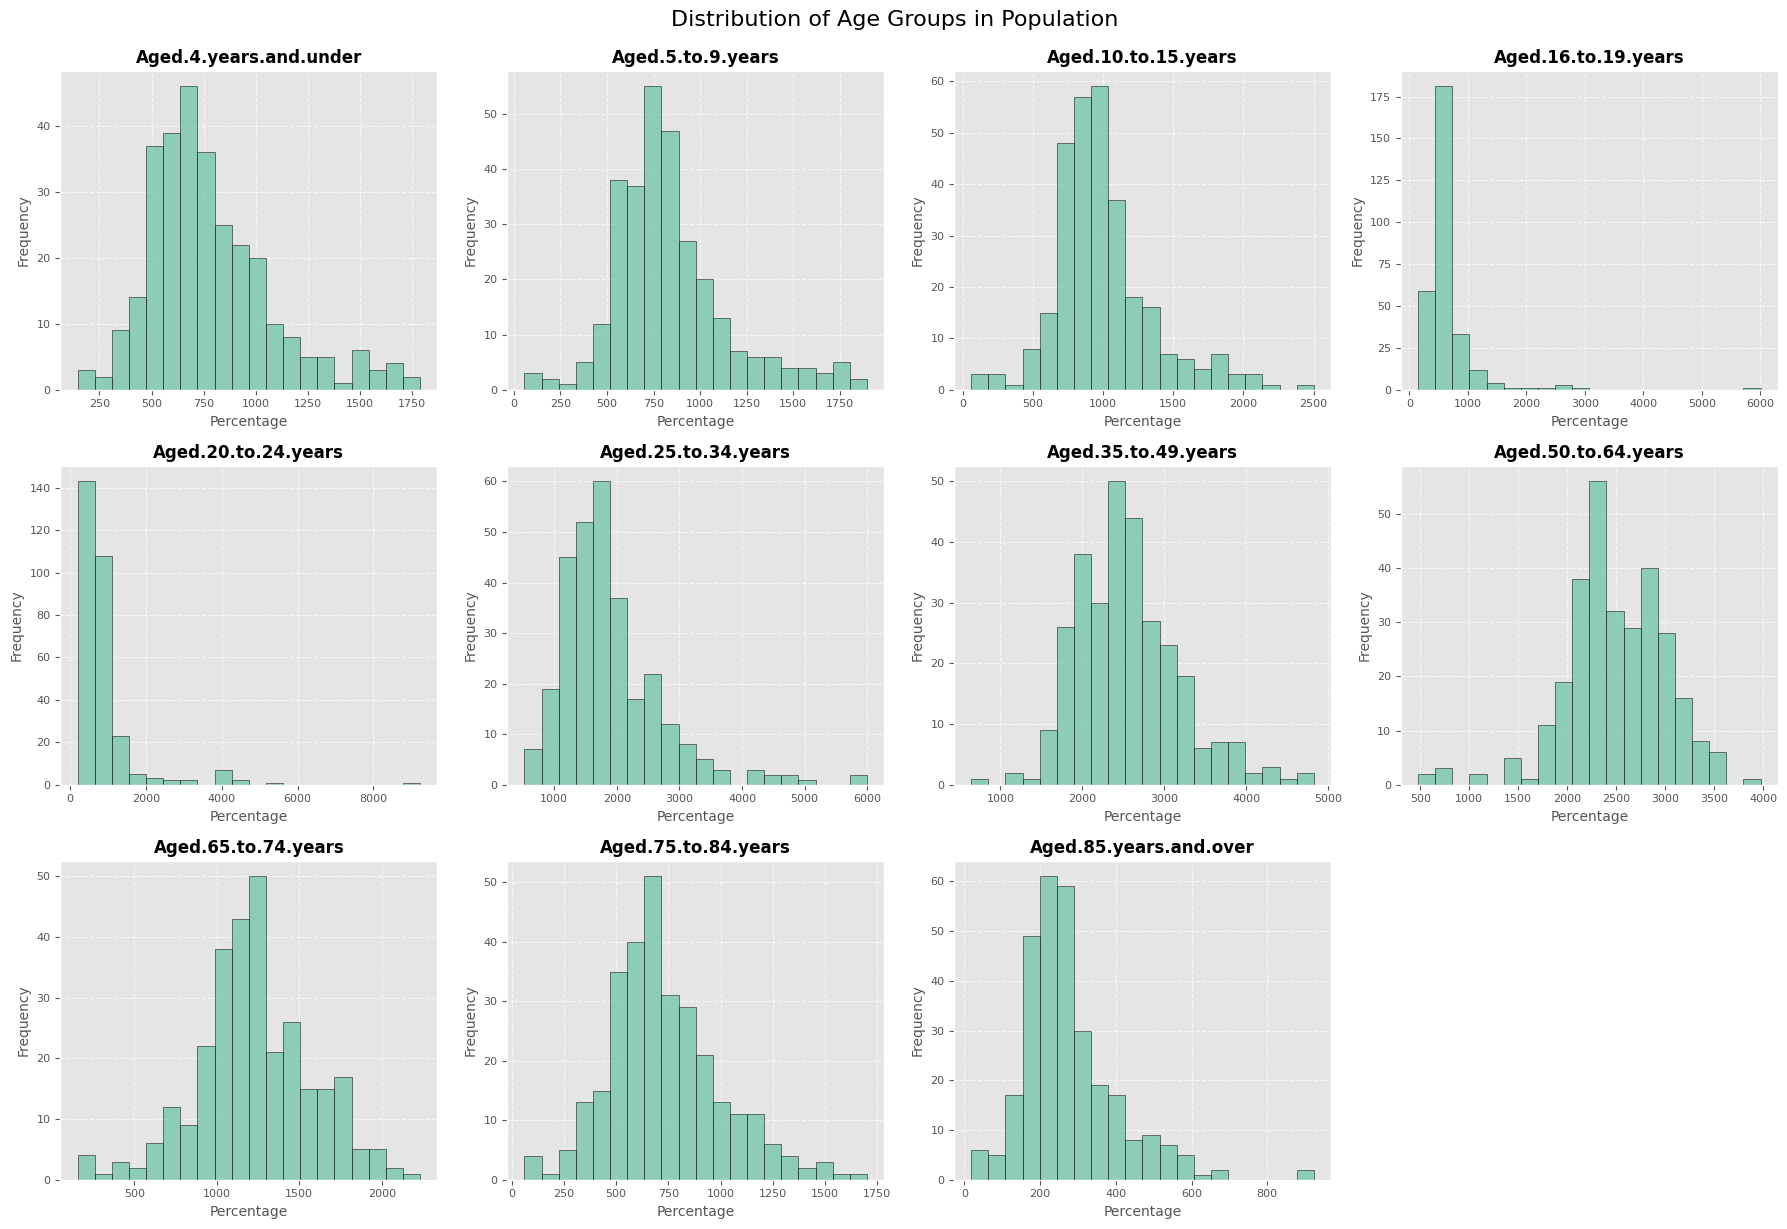

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
sns.set_palette("Set2")


fig = plt.figure(figsize=(18, 12))

for i, column in enumerate(age_columns.columns):
    ax = fig.add_subplot(3, 4, i+1)

    ax.hist(age_columns[column], bins=20, alpha=0.7, edgecolor='black')

    ax.set_title(column.replace('_', ' '), fontsize=12, fontweight='bold')
    ax.set_xlabel('Percentage', fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)

    ax.grid(True, linestyle='--', alpha=0.7)

    ax.tick_params(axis='both', labelsize=8)


plt.tight_layout()


plt.suptitle('Distribution of Age Groups in Population', fontsize=16, y=1.02)
plt.show()

In [54]:
results['youth'] = results[['Aged.4.years.and.under', 'Aged.5.to.9.years','Aged.10.to.15.years']].sum(axis=1)
results['adult'] = results[['Aged.16.to.19.years', 'Aged.20.to.24.years', 'Aged.25.to.34.years', 'Aged.35.to.49.years', 'Aged.50.to.64.years']].sum(axis=1)
results['old'] = results[['Aged.65.to.74.years', 'Aged.75.to.84.years', 'Aged.85.years.and.over']].sum(axis=1)

results[['youth', 'adult', 'old']].describe()

,youth,adult,old
count,297.000000,297.000000,297.000000
mean,2609.858586,8493.265993,2236.134680
std,941.355173,2364.248631,721.943128
min,286.000000,2115.000000,246.000000
25%,2005.000000,6907.000000,1808.000000
50%,2420.000000,8086.000000,2150.000000
75%,2960.000000,9424.000000,2647.000000
max,6126.000000,23149.000000,4639.000000


In [55]:
results['total_population'] = results[['youth', 'adult', 'old']].sum(axis=1)

results['youth_ratio'] = results['youth'] / results['total_population']
results['adult_ratio'] = results['adult'] / results['total_population']
results['old_ratio'] = results['old'] / results['total_population']

results['youthp'] = results['youth_ratio'] * 100
results['adultp'] = results['adult_ratio'] * 100
results['oldp'] = results['old_ratio'] * 100

results[['youthp', 'adultp', 'oldp']].describe()

,youthp,adultp,oldp
count,297.000000,297.000000,297.000000
mean,19.356767,63.241649,17.401584
std,4.237419,6.247675,6.132241
min,2.322863,51.792988,1.804237
25%,16.994143,60.443089,13.452951
50%,19.073695,62.440673,17.407957
75%,21.497827,64.303329,21.195652
max,30.554863,95.872900,37.049756


### 13. No of school

In [56]:
results['numberofschools'].describe()

,numberofschools
count,297.000000
mean,7.521886
std,4.942954
min,0.000000
25%,4.000000
50%,7.000000
75%,10.000000
max,27.000000


# <2. Regression Model>

In [57]:
added_columns = results.columns[-40:]
added_columns

Index(['meanyear2021', 'numberofschools', 'high_value', 'below_high_value',
       'low_value', 'ratio', 'goodhealthp', 'disabledp', 'Deprived0p',
       'Deprived1p', 'Deprived24p', 'tenureownp', 'socrentp', 'privrentp',
       'employeep', 'selfemployeep', 'nonemployedp', 'ethnwhitep',
       'ethnotherp', 'nssec1', 'nssec2', 'nssec3', 'nssec4', 'nssec5',
       'popdensity', '1carp', '23carp', 'lowhousingp', 'midhousingp',
       'highhousingp', 'youth', 'adult', 'old', 'total_population',
       'youth_ratio', 'adult_ratio', 'old_ratio', 'youthp', 'adultp', 'oldp'],
      dtype='object')

In [58]:
# Total: 29 columns
data = results[['goodhealthp',
       'disabledp',
       'Deprived0p', 'Deprived1p', 'Deprived24p',
       'tenureownp', 'socrentp', 'privrentp',
       'employeep', 'selfemployeep', 'nonemployedp',
       'ethnwhitep', 'ethnotherp',
       'nssec1', 'nssec2', 'nssec3', 'nssec4', 'nssec5',
       'popdensity',
       'nocarp', '1carp', '23carp',
       'lowhousingp', 'midhousingp', 'highhousingp',
       'youthp', 'oldp',  # Especially the variables youthp, adultp, and oldp appear to represent the proportions of the total population, and if their sum is calculated to be 1 (or 100%), perfect multicollinearity will occur. This is because if the sum of the three proportions is always 1, knowing any two variables automatically determines the remaining one.
       'numberofschools']]


data.describe()

,goodhealthp,disabledp,Deprived0p,Deprived1p,Deprived24p,tenureownp,socrentp,privrentp,employeep,selfemployeep,...,popdensity,nocarp,1carp,23carp,lowhousingp,midhousingp,highhousingp,youthp,oldp,numberofschools
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,...,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,80.286532,80.401684,45.215152,33.126263,21.658923,59.186195,20.092256,19.952525,45.821549,7.684512,...,25.777957,27.787205,42.533333,29.683502,33.517845,62.354882,4.125253,19.356767,17.401584,7.521886
std,3.692298,3.600961,8.816838,2.194369,7.335806,18.029871,12.182302,11.061853,5.867945,1.563270,...,16.212633,11.855899,3.090296,10.951504,14.639778,13.827403,3.966294,4.237419,6.132241,4.942954
min,70.700000,70.500000,23.500000,24.100000,5.000000,14.500000,1.600000,6.200000,22.400000,3.000000,...,0.000000,8.300000,27.600000,4.300000,7.000000,5.000000,0.000000,2.322863,1.804237,0.000000
25%,78.000000,78.500000,38.600000,32.000000,16.200000,47.000000,10.000000,12.900000,43.300000,6.600000,...,13.832579,18.800000,41.000000,21.600000,23.200000,54.400000,1.600000,16.994143,13.452951,4.000000
50%,80.200000,80.600000,44.900000,33.400000,21.300000,61.700000,17.900000,16.800000,46.500000,7.500000,...,24.773713,25.800000,42.900000,29.900000,31.400000,63.400000,2.900000,19.073695,17.407957,7.000000
75%,82.400000,82.700000,51.000000,34.500000,26.900000,73.500000,27.400000,23.400000,49.400000,8.500000,...,35.472060,35.300000,44.500000,37.700000,41.500000,72.200000,5.300000,21.497827,21.195652,10.000000
max,93.200000,89.800000,70.300000,37.900000,40.800000,90.700000,55.800000,78.400000,66.600000,14.000000,...,100.000000,68.100000,50.200000,57.500000,94.800000,90.700000,29.100000,30.554863,37.049756,27.000000


In [59]:
# New variables

cdf = pd.DataFrame(results['high_value'])  # continous
adf = data

## <2.1. OLS>

In [60]:
from statsmodels import api as sm

xdf = sm.add_constant(adf)
OLS = sm.OLS(cdf, xdf).fit()
OLS.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             high_value   R-squared:                       0.985
Model:                            OLS   Adj. R-squared:                  0.984
Method:                 Least Squares   F-statistic:                     639.3
Date:                Tue, 18 Mar 2025   Prob (F-statistic):          4.84e-228
Time:                        14:56:22   Log-Likelihood:                -488.50
No. Observations:                 297   AIC:                             1035.
Df Residuals:                     268   BIC:                             1142.
Df Model:                          28                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             343.1907    270.423      1.269      0.206    -189.234     875.615
goodhealthp         0.6721      0.183      3.668      0.000       0.311       1.033
disabledp          -0.8325      0.145     -5.748      0.000      -1.118      -0.547
Deprived0p         -1.1924      1.279     -0.932      0.352      -3.711       1.326
Deprived1p         -1.5579      1.287     -1.210      0.227      -4.092       0.977
Deprived24p        -1.4051      1.280     -1.098      0.273      -3.925       1.115
tenureownp          0.1158      0.177      0.654      0.514      -0.233       0.465
socrentp            0.2476      0.178      1.389      0.166      -0.103       0.599
privrentp           0.2904      0.178      1.633      0.104      -0.060       0.641
employeep          -0.2310      0.208     -1.112      0.267      -0.640       0.178
selfemployeep       0.4744      0.258      1.836      0.067      -0.034       0.983
nonemployedp       -0.1927      0.194     -0.994      0.321      -0.575       0.189
ethnwhitep          0.3486      1.168      0.298      0.766      -1.952       2.649
ethnotherp          0.5606      1.168      0.480      0.632      -1.739       2.861
nssec1              0.1639      0.947      0.173      0.863      -1.700       2.028
nssec2             -0.6806      0.953     -0.714      0.476      -2.557       1.196
nssec3             -1.5918      0.952     -1.673      0.096      -3.465       0.282
nssec4             -0.9670      0.953     -1.015      0.311      -2.843       0.909
nssec5             -1.1123      0.946     -1.176      0.241      -2.974       0.750
popdensity         -0.0067      0.009     -0.781      0.435      -0.023       0.010
nocarp             -0.6257      1.487     -0.421      0.674      -3.554       2.302
1carp              -0.5738      1.490     -0.385      0.700      -3.507       2.359
23carp             -0.6832      1.489     -0.459      0.647      -3.615       2.249
lowhousingp        -0.5419      0.927     -0.585      0.559      -2.366       1.282
midhousingp        -0.4799      0.926     -0.518      0.605      -2.302       1.342
highhousingp       -0.5555      0.929     -0.598      0.550      -2.385       1.274
youthp             -0.2709      0.070     -3.887      0.000      -0.408      -0.134
oldp                0.0381      0.099      0.384      0.701      -0.157       0.233
numberofschools     0.0329      0.021      1.581      0.115      -0.008       0.074
==============================================================================
Omnibus:                        0.021   Durbin-Watson:                   1.769
Prob(Omnibus):                  0.990   Jarque-Bera (JB):                0.103
Skew:                          -0.002   Prob(JB):                        0.950
Kurtosis:                       2.909   Cond. No.                     7.43e+05


In [61]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.Series([variance_inflation_factor(xdf.values, i)
                       for i in range(xdf.shape[1])],
                      index=xdf.columns)

vif_data = pd.DataFrame(vif_data, columns=['VIF'])
vif_data

,VIF
const,1.247532e+07
goodhealthp,7.782270e+01
disabledp,4.624315e+01
Deprived0p,2.161986e+04
Deprived1p,1.356642e+03
Deprived24p,1.498616e+04
tenureownp,1.734093e+03
socrentp,8.024411e+02
privrentp,6.581503e+02
employeep,2.528404e+02


In [62]:
results['prediction1'] = OLS.fittedvalues
results['residual1'] = results['high_value'] - results['prediction1']
results['residual1'].head(1)

,residual1
0,-1.30598


## <2.2. Correlation>

In [63]:
correlation = adf.corr()
correlation

,goodhealthp,disabledp,Deprived0p,Deprived1p,Deprived24p,tenureownp,socrentp,privrentp,employeep,selfemployeep,...,popdensity,nocarp,1carp,23carp,lowhousingp,midhousingp,highhousingp,youthp,oldp,numberofschools
goodhealthp,1.000000,0.944903,0.780773,-0.579295,-0.764544,0.277759,-0.567684,0.186204,0.198694,0.573112,...,0.086823,-0.354468,0.012102,0.379981,0.046300,-0.173578,0.434784,-0.265401,-0.054531,-0.256025
disabledp,0.944903,1.000000,0.628110,-0.417707,-0.629205,0.239341,-0.482974,0.155001,0.130495,0.587906,...,0.115659,-0.328872,0.041775,0.344011,0.121142,-0.227351,0.345431,-0.064561,-0.122448,-0.265223
Deprived0p,0.780773,0.628110,1.000000,-0.741981,-0.979505,0.618696,-0.796999,-0.114176,0.481338,0.618626,...,-0.311153,-0.630270,0.108342,0.651577,-0.219399,0.083313,0.519035,-0.564934,0.422808,-0.355545
Deprived1p,-0.579295,-0.417707,-0.741981,1.000000,0.591859,-0.176255,0.340908,-0.093806,-0.468927,-0.380334,...,0.084083,0.194149,0.066300,-0.228757,0.060913,0.027682,-0.320994,0.408138,-0.013353,0.146990
Deprived24p,-0.764544,-0.629205,-0.979505,0.591859,1.000000,-0.690489,0.856000,0.164594,-0.437938,-0.629501,...,0.348896,0.699129,-0.149925,-0.714392,0.245172,-0.108162,-0.527580,0.557245,-0.504204,0.383445
tenureownp,0.277759,0.239341,0.618696,-0.176255,-0.690489,1.000000,-0.796937,-0.736577,0.331251,0.579812,...,-0.606829,-0.950317,0.300660,0.944080,-0.678920,0.590519,0.446142,-0.175711,0.837863,-0.427334
socrentp,-0.567684,-0.482974,-0.796999,0.340908,0.856000,-0.796937,1.000000,0.179207,-0.337408,-0.596699,...,0.339653,0.732395,-0.213886,-0.732477,0.339500,-0.211981,-0.513533,0.487215,-0.605923,0.461572
privrentp,0.186204,0.155001,-0.114176,-0.093806,0.164594,-0.736577,0.179207,1.000000,-0.164155,-0.276406,...,0.607852,0.728637,-0.254342,-0.717292,0.727268,-0.726639,-0.150025,-0.260172,-0.686774,0.178709
employeep,0.198694,0.130495,0.481338,-0.468927,-0.437938,0.331251,-0.337408,-0.164155,1.000000,0.216653,...,-0.253933,-0.355419,0.472136,0.252193,-0.088095,0.149585,-0.197609,-0.153916,0.101564,-0.249438
selfemployeep,0.573112,0.587906,0.618626,-0.380334,-0.629501,0.579812,-0.596699,-0.276406,0.216653,1.000000,...,-0.255521,-0.642310,0.198818,0.639083,-0.234556,0.060188,0.655526,0.046098,0.365917,-0.274785


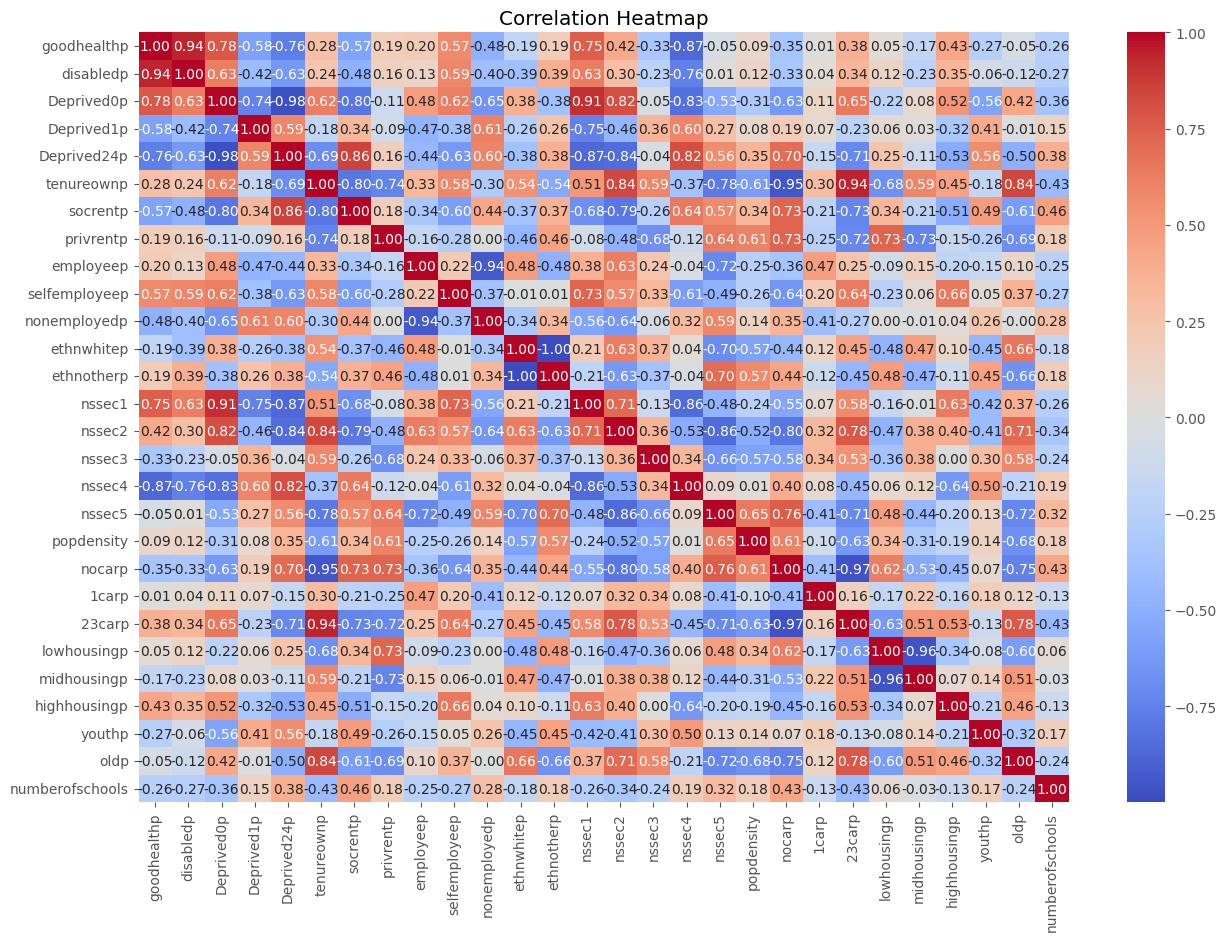

In [64]:
plt.figure(figsize=(15, 10))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [65]:
data['manage_nssec'] = data[['nssec1', 'nssec2']].sum(axis=1)

data2 = data[['disabledp','Deprived24p','socrentp','nonemployedp',
              'ethnotherp','manage_nssec','nocarp','midhousingp', 'oldp','numberofschools']]

data2_correlation = data2.corr()
data2_correlation

,disabledp,Deprived24p,socrentp,nonemployedp,ethnotherp,manage_nssec,nocarp,midhousingp,oldp,numberofschools
disabledp,1.000000,-0.629205,-0.482974,-0.396783,0.385391,0.489228,-0.328872,-0.227351,-0.122448,-0.265223
Deprived24p,-0.629205,1.000000,0.856000,0.601281,0.377012,-0.926958,0.699129,-0.108162,-0.504204,0.383445
socrentp,-0.482974,0.856000,1.000000,0.436309,0.373764,-0.795881,0.732395,-0.211981,-0.605923,0.461572
nonemployedp,-0.396783,0.601281,0.436309,1.000000,0.341886,-0.647066,0.353682,-0.013948,-0.000092,0.279696
ethnotherp,0.385391,0.377012,0.373764,0.341886,1.000000,-0.465104,0.444705,-0.474295,-0.660010,0.179494
manage_nssec,0.489228,-0.926958,-0.795881,-0.647066,-0.465104,1.000000,-0.738522,0.214361,0.595502,-0.327386
nocarp,-0.328872,0.699129,0.732395,0.353682,0.444705,-0.738522,1.000000,-0.531903,-0.748702,0.430085
midhousingp,-0.227351,-0.108162,-0.211981,-0.013948,-0.474295,0.214361,-0.531903,1.000000,0.505412,-0.028560
oldp,-0.122448,-0.504204,-0.605923,-0.000092,-0.660010,0.595502,-0.748702,0.505412,1.000000,-0.240827
numberofschools,-0.265223,0.383445,0.461572,0.279696,0.179494,-0.327386,0.430085,-0.028560,-0.240827,1.000000


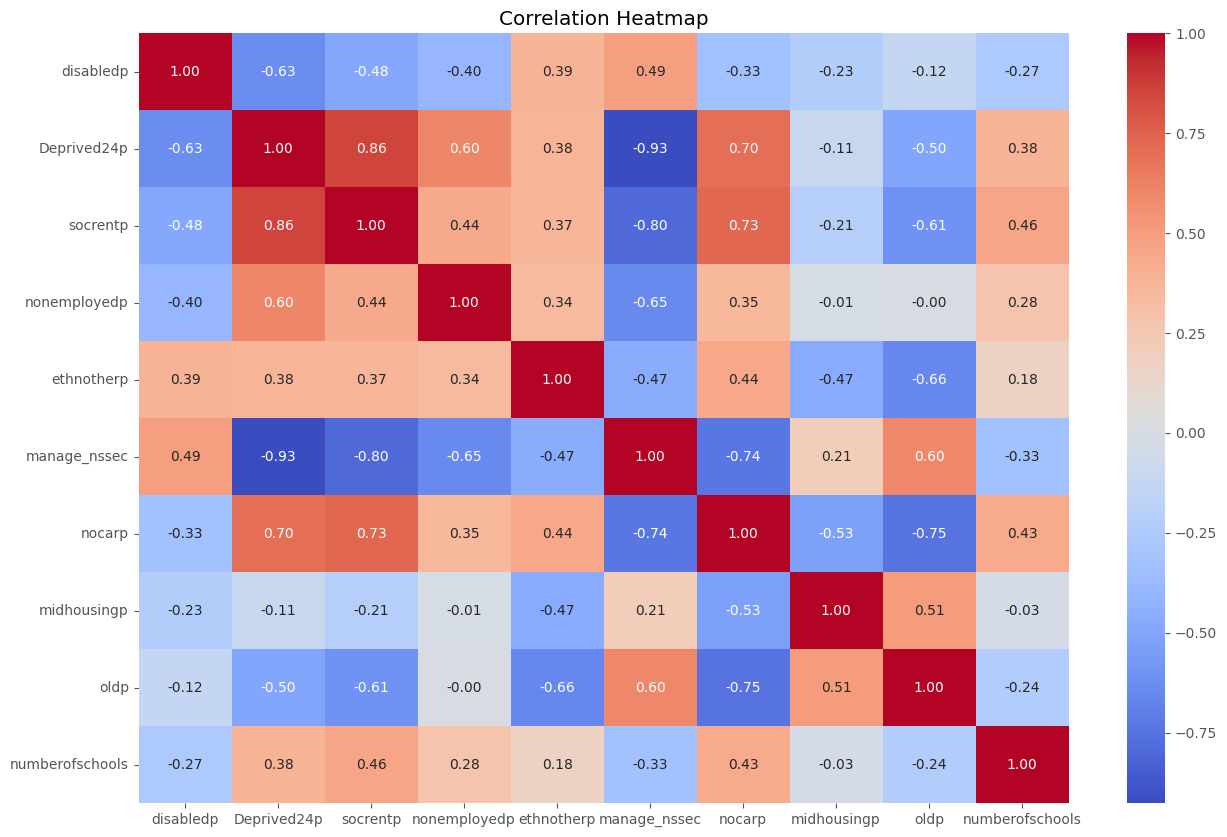

In [66]:
plt.figure(figsize=(15, 10))
sns.heatmap(data2_correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [67]:
high_corr = data2_correlation[((data2_correlation > 0.7) | (data2_correlation < -0.7))]
high_corr

,disabledp,Deprived24p,socrentp,nonemployedp,ethnotherp,manage_nssec,nocarp,midhousingp,oldp,numberofschools
disabledp,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Deprived24p,NaN,1.000000,0.856000,NaN,NaN,-0.926958,NaN,NaN,NaN,NaN
socrentp,NaN,0.856000,1.000000,NaN,NaN,-0.795881,0.732395,NaN,NaN,NaN
nonemployedp,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN
ethnotherp,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
manage_nssec,NaN,-0.926958,-0.795881,NaN,NaN,1.000000,-0.738522,NaN,NaN,NaN
nocarp,NaN,NaN,0.732395,NaN,NaN,-0.738522,1.000000,NaN,-0.748702,NaN
midhousingp,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
oldp,NaN,NaN,NaN,NaN,NaN,NaN,-0.748702,NaN,1.000000,NaN
numberofschools,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


In [68]:
# VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = data2.columns
vif_data["VIF"] = [variance_inflation_factor(data2.values, i) for i in range(data2.shape[1])]

vif_data['VIF'] = pd.to_numeric(vif_data['VIF'])

vif_data.sort_values('VIF', ascending=False)

,Variable,VIF
0,disabledp,529.595491
3,nonemployedp,373.308111
5,manage_nssec,199.868910
8,oldp,113.890262
1,Deprived24p,95.688754
7,midhousingp,48.740362
6,nocarp,42.700800
2,socrentp,19.425764
4,ethnotherp,8.299094
9,numberofschools,4.959317


In [69]:
# Target : Highlty_educated!!
results['highly_educated'] = (results['Qualification_Level_4_Or_Above_Percentage'] > results['Qualification_Level_4_Or_Above_Percentage'].mean()).astype(int)

cdf = results['highly_educated']

# Extracting only some variables (due to multicollinearity)
adf = data2

xdf = sm.add_constant(adf)

logr = sm.Logit(cdf,xdf).fit()

print(logr.summary())

Optimization terminated successfully.
         Current function value: 0.126929
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:        highly_educated   No. Observations:                  297
Model:                          Logit   Df Residuals:                      286
Method:                           MLE   Df Model:                           10
Date:                Tue, 18 Mar 2025   Pseudo R-squ.:                  0.8122
Time:                        14:56:28   Log-Likelihood:                -37.698
converged:                       True   LL-Null:                       -200.74
Covariance Type:            nonrobust   LLR p-value:                 4.680e-64
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              25.5129     31.849      0.801      0.423     -36.910      87.936
disabledp    

In [70]:
from sklearn.metrics import confusion_matrix
plogr = logr.predict(xdf)

y_true_binary = results['highly_educated']

plogr2 = list(map(round,plogr))

cm = confusion_matrix(y_true_binary, plogr2)
cm

array([[167,   9],
       [ 10, 111]])

<Axes: >

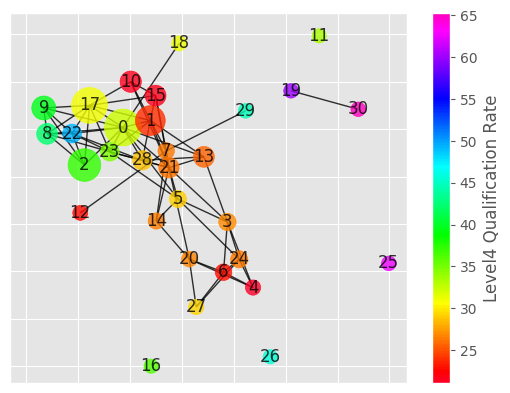

In [71]:
import pyballmapper as pbm
import networkx as nx
from matplotlib import colormaps as cm

hsvp = cm.get_cmap("gist_rainbow")

adf = data2

cdf = pd.DataFrame(results['high_value'])

bm1 = pbm.BallMapper(X=adf, eps=25, coloring_df=cdf)

bm1.draw_networkx(coloring_variable='high_value',
                  color_palette=hsvp,
                  colorbar=True,
                  colorbar_label="Level4 Qualification Rate",
                  pos=nx.spring_layout(bm1.Graph, k=0.6, seed=4))

<Axes: >

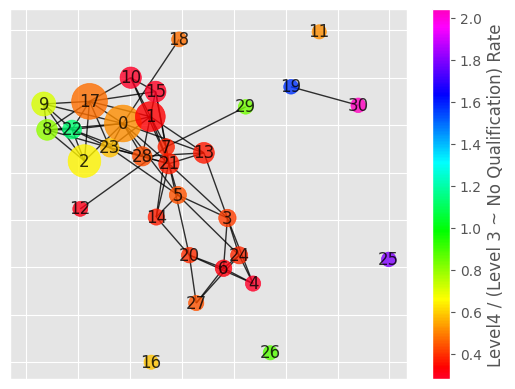

In [122]:
adf = data2

cdf = pd.DataFrame(results['ratio'])

bm1 = pbm.BallMapper(X=adf, eps=25, coloring_df=cdf)

bm1.draw_networkx(coloring_variable='ratio',
                  color_palette=hsvp,
                  colorbar=True,
                  colorbar_label="Level4 / (Level 3 ~ No Qualification) Rate",
                  pos=nx.spring_layout(bm1.Graph, k=0.6, seed=4))

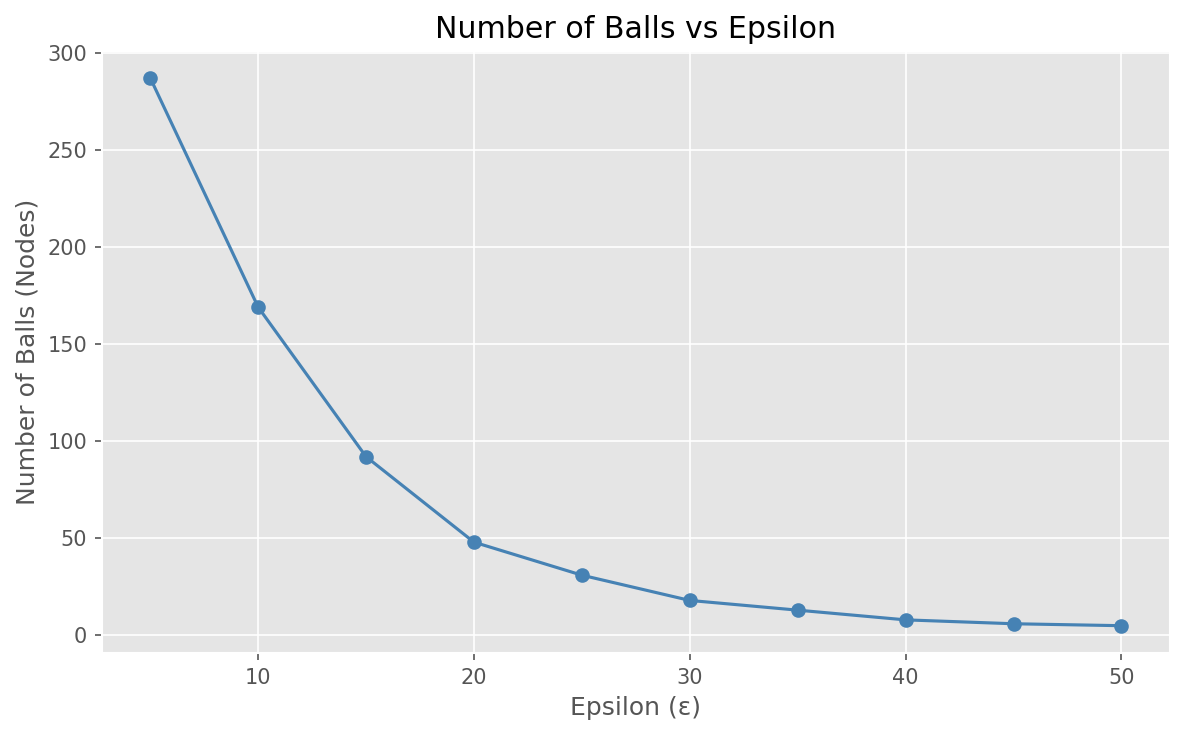

In [128]:
eps_values = list(range(5, 51, 5))
ball_counts = []

cdf = pd.DataFrame(results['high_value'])

for eps in eps_values:
    bm = pbm.BallMapper(X=adf, eps=eps, coloring_df=cdf)
    ball_counts.append(len(bm.Graph.nodes))

plt.figure(figsize=(8, 5), dpi=100)
plt.plot(eps_values, ball_counts, marker='o', linestyle='-', color='steelblue')
plt.title("Number of Balls vs Epsilon")
plt.xlabel("Epsilon (ε)")
plt.ylabel("Number of Balls (Nodes)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [73]:
pb1 = bm1.points_and_balls()

results['manage_nssec']=data2['manage_nssec']

data['point'] = data.index
results['point'] = results.index

fulld = data.merge(pb1, on='point')
subd = results.merge(pb1, on='point')

ballslist = pd.DataFrame(subd[["ball","Ward_Code","WD22NM",'high_value', 'disabledp','Deprived24p','socrentp','nonemployedp',
                              'ethnotherp','manage_nssec','nocarp','midhousingp', 'oldp','numberofschools']])

shape2 = shape.merge(results[['Ward_Code','high_value', 'disabledp','Deprived24p','socrentp','nonemployedp',
                              'ethnotherp','manage_nssec','nocarp','midhousingp', 'oldp','numberofschools']], on='Ward_Code', how='left')

In [74]:
ballslist = ballslist.drop_duplicates(subset=['Ward_Code'])
ballslist.sort_values('ball', ascending=True)

,ball,Ward_Code,WD22NM,high_value,disabledp,Deprived24p,socrentp,nonemployedp,ethnotherp,manage_nssec,nocarp,midhousingp,oldp,numberofschools
0,0,E05000650,Astley Bridge,30.7,82.7,17.0,13.7,42.5,21.8,46.4,20.2,57.6,19.393168,4.0
1,0,E05000651,Bradshaw,32.5,81.4,15.9,13.4,48.2,6.4,50.8,16.1,71.1,27.228581,4.0
666,0,E05014168,Unsworth,31.8,81.9,17.3,11.3,42.2,12.6,49.9,17.9,70.6,21.536090,10.0
663,0,E05014167,Tottington,33.3,81.9,12.4,4.5,39.3,4.2,52.7,12.2,64.2,21.959694,4.0
660,0,E05014166,St. Mary's,41.8,80.0,17.8,17.7,40.3,18.1,52.6,23.2,60.5,17.471855,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456,26,E05011368,Hulme,45.9,85.0,17.6,35.7,43.3,42.4,34.8,52.5,25.0,3.609385,20.0
458,27,E05011370,Longsight,26.2,84.3,31.9,37.2,51.6,76.9,22.5,37.2,66.7,7.012838,21.0
503,28,E05013026,Kersal & Broughton Park,28.9,86.2,21.4,21.1,41.7,21.1,45.3,33.1,46.4,11.795511,22.0
507,29,E05013028,Ordsall,47.0,83.3,20.7,35.9,33.6,29.4,45.3,49.3,31.0,7.792208,4.0


In [75]:
ballslist.groupby('ball')[['high_value','disabledp','Deprived24p','socrentp','nonemployedp',
'ethnotherp','manage_nssec','nocarp','midhousingp', 'oldp','numberofschools']].mean().sort_index(ascending=True)

,high_value,disabledp,Deprived24p,socrentp,nonemployedp,ethnotherp,manage_nssec,nocarp,midhousingp,oldp,numberofschools
ball,,,,,,,,,,,
0,32.233043,81.157391,18.607826,15.074783,41.502609,12.997391,47.018261,21.907826,61.797391,19.001386,5.217391
1,22.872727,76.261364,28.638636,32.961364,45.938636,11.393182,33.563636,34.606818,64.859091,15.810396,9.863636
2,40.044737,82.431579,12.805263,6.036842,44.194737,5.568421,56.889474,13.815789,72.368421,25.906970,6.657895
3,26.936364,81.927273,28.363636,27.872727,47.472727,49.263636,30.981818,33.854545,49.400000,11.389169,7.363636
4,20.666667,80.100000,35.433333,40.000000,54.100000,51.266667,22.633333,43.300000,36.266667,10.874739,5.333333
5,32.000000,82.100000,24.816667,27.100000,47.300000,41.900000,33.450000,31.566667,68.400000,10.953181,8.000000
6,23.014286,84.200000,34.842857,28.542857,54.100000,78.071429,21.985714,37.800000,45.628571,8.287279,7.714286
7,27.900000,76.816667,30.316667,40.883333,47.966667,20.516667,30.216667,50.683333,44.283333,10.993280,14.166667
8,49.450000,84.250000,12.650000,5.600000,39.600000,28.500000,58.250000,15.600000,72.850000,18.838273,6.500000


In [76]:
# Purple - High
subset1 = ballslist[ballslist['ball'].isin([19, 30])]
subset1

,ball,Ward_Code,WD22NM,high_value,disabledp,Deprived24p,socrentp,nonemployedp,ethnotherp,manage_nssec,nocarp,midhousingp,oldp,numberofschools
423,19,E05011350,Ancoats & Beswick,60.0,85.3,14.4,22.4,25.9,32.4,58.4,47.4,26.1,5.727972,16.0
485,19,E05013019,Blackfriars & Trinity,60.0,86.9,12.8,18.5,25.6,28.6,55.1,56.7,15.4,2.507042,2.0
513,30,E05013031,Quays,70.5,89.6,7.5,6.0,19.2,29.8,64.4,45.6,11.4,2.645446,4.0


In [77]:
# Mid-High connected
subset2 = ballslist[ballslist['ball'].isin([25,26])]
subset2

,ball,Ward_Code,WD22NM,high_value,disabledp,Deprived24p,socrentp,nonemployedp,ethnotherp,manage_nssec,nocarp,midhousingp,oldp,numberofschools
443,25,E05011361,Deansgate,60.2,89.8,5.0,4.0,41.4,37.1,44.6,60.7,5.0,1.804237,4.0
456,26,E05011368,Hulme,45.9,85.0,17.6,35.7,43.3,42.4,34.8,52.5,25.0,3.609385,20.0
472,25,E05011376,Piccadilly,65.0,88.5,9.0,9.3,31.2,30.3,53.5,68.1,7.1,2.548481,6.0


In [78]:
# Mid-High connected
subset3 = ballslist[ballslist['ball'].isin([8,22])]
subset3

,ball,Ward_Code,WD22NM,high_value,disabledp,Deprived24p,socrentp,nonemployedp,ethnotherp,manage_nssec,nocarp,midhousingp,oldp,numberofschools
121,8,E05000790,Heald Green,36.7,82.7,14.5,4.7,44.9,31.0,52.0,12.4,78.4,22.611222,2.0
439,22,E05011357,Chorlton,65.0,84.8,11.6,8.1,29.6,20.0,64.8,23.6,52.6,12.427971,10.0
444,8,E05011362,Didsbury East,62.2,85.8,10.8,6.5,34.3,26.0,64.5,18.8,67.3,15.065324,11.0
446,22,E05011363,Didsbury West,71.0,86.6,9.3,7.9,27.4,19.5,70.2,25.3,34.3,11.439751,13.0


In [79]:
shape2 = shape2.merge(ballslist[['Ward_Code', 'high_value', 'disabledp', 'Deprived24p', 'socrentp', 'nonemployedp',
                               'ethnotherp', 'manage_nssec', 'nocarp', 'midhousingp', 'oldp', 'numberofschools', 'ball']],
                      on='Ward_Code', how='inner')

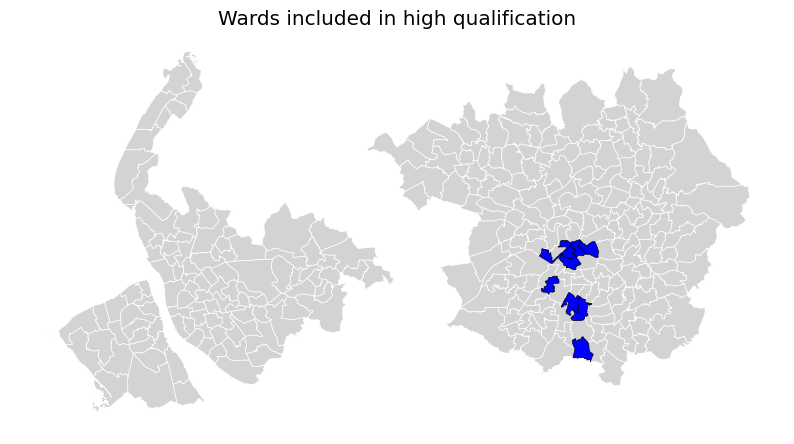

In [80]:
wards1 = subset1['Ward_Code'].unique()
wards2 = subset2['Ward_Code'].unique()
wards3 = subset3['Ward_Code'].unique()

all_wards_high = np.union1d(np.union1d(wards1, wards2), wards3)

highlight_shape = shape[shape['Ward_Code'].isin(all_wards_high)]

fig, ax = plt.subplots(figsize=(10, 10))
shape2.plot(ax=ax, color='lightgrey', edgecolor='white')
highlight_shape.plot(ax=ax, color='blue', edgecolor='black')

plt.title("Wards included in high qualification")
plt.axis('off')
plt.show()

In [81]:
# Red - Low connected
subset4 = ballslist[ballslist['ball'].isin([10,15])]
subset4

,ball,Ward_Code,WD22NM,high_value,disabledp,Deprived24p,socrentp,nonemployedp,ethnotherp,manage_nssec,nocarp,midhousingp,oldp,numberofschools
249,10,E05000887,Anfield,21.1,76.0,30.9,24.5,49.5,15.5,28.7,49.7,73.7,14.392396,7.0
260,10,E05000892,Clubmoor,19.1,73.5,33.7,40.0,49.6,7.4,29.9,40.4,86.6,16.966419,12.0
262,10,E05000893,County,20.8,73.8,33.4,25.2,49.4,8.9,27.5,53.7,69.8,15.514296,8.0
270,10,E05000897,Fazakerley,24.9,76.3,26.2,15.9,43.4,6.8,38.7,34.0,79.8,15.033598,12.0
276,10,E05000901,Knotty Ash,26.9,77.5,26.4,26.5,46.4,7.8,39.8,35.1,80.6,19.417746,7.0
283,15,E05000903,Norris Green,22.7,76.4,31.8,45.9,45.1,11.0,29.9,38.2,81.8,11.483351,12.0
284,10,E05000904,Old Swan,25.6,75.0,27.4,19.5,46.4,13.8,35.6,43.8,71.7,16.764894,10.0
294,10,E05000910,Tuebrook and Stoneycroft,25.7,76.4,29.6,17.8,47.3,17.1,32.3,46.2,67.9,14.332805,5.0
295,10,E05000911,Warbreck,24.2,77.2,24.5,14.6,43.6,5.8,38.1,34.5,73.0,16.034304,4.0
326,10,E05000943,Litherland,21.5,77.9,25.8,23.2,41.5,3.9,38.7,36.8,76.7,15.906268,9.0


In [82]:
# Red - Low connected

subset5 = ballslist[ballslist['ball'].isin([4,6,12])]
subset5

,ball,Ward_Code,WD22NM,high_value,disabledp,Deprived24p,socrentp,nonemployedp,ethnotherp,manage_nssec,nocarp,midhousingp,oldp,numberofschools
14,4,E05000657,Halliwell,20.9,81.0,36.1,37.7,55.9,57.4,20.1,46.2,31.8,10.812473,5.0
31,6,E05000665,Rumworth,20.8,84.9,35.7,27.1,54.0,78.9,21.8,36.2,39.6,9.582920,3.0
43,4,E05000719,Alexandra,19.2,80.4,37.5,42.9,57.4,54.5,20.0,39.4,44.6,9.557449,4.0
53,6,E05000723,Coldhurst,18.1,83.5,40.8,42.5,57.1,79.0,18.3,46.6,43.0,8.125351,7.0
83,6,E05000735,St Mary's,19.3,84.0,37.0,29.4,55.0,75.4,18.8,36.2,48.4,7.663619,7.0
89,6,E05000738,Werneth,22.5,85.1,34.7,25.9,54.7,82.7,22.2,31.0,51.9,8.496864,8.0
184,4,E05000816,St Peter's,21.9,78.9,32.7,39.4,49.0,41.9,27.8,44.3,32.4,12.254296,7.0
269,12,E05000896,Everton,22.9,72.3,38.6,54.4,56.7,21.2,22.9,55.6,52.5,15.689645,27.0
325,12,E05000942,Linacre,19.2,71.3,36.8,44.9,51.6,8.2,26.7,54.9,59.1,14.248971,15.0
436,6,E05011356,Cheetham,35.1,85.2,26.0,27.1,47.9,73.3,29.5,39.7,48.9,5.956317,15.0


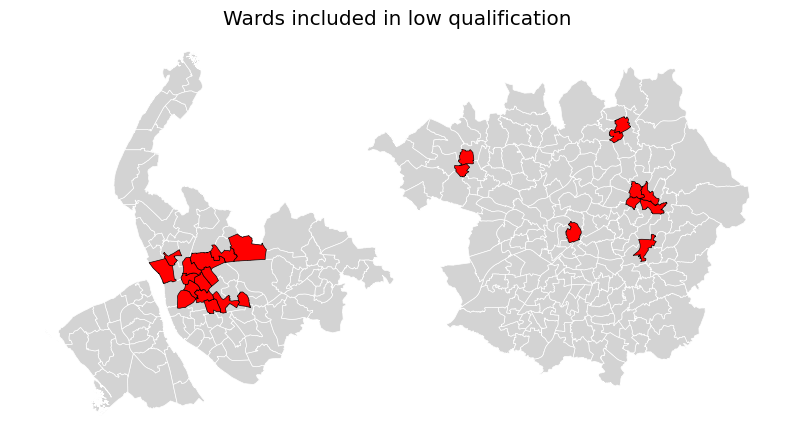

In [83]:
wards4 = subset4['Ward_Code'].unique()
wards5 = subset5['Ward_Code'].unique()

all_wards_low = np.union1d(wards4, wards5)

highlight_shape = shape[shape['Ward_Code'].isin(all_wards_low)]

fig, ax = plt.subplots(figsize=(10, 10))
shape2.plot(ax=ax, color='lightgrey', edgecolor='white')
highlight_shape.plot(ax=ax, color='red', edgecolor='black')

plt.title("Wards included in low qualification")
plt.axis('off')
plt.show()

# <3. Robutness>



### 3.1. hyperparameter tunning

<Axes: >

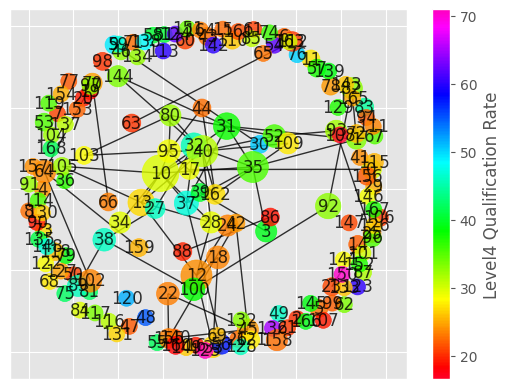

In [84]:
##### 1. EPS

hsvp = cm.get_cmap("gist_rainbow")

adf = data2

cdf = pd.DataFrame(results['high_value'])

bm1 = pbm.BallMapper(X=adf, eps=10, coloring_df=cdf)

bm1.draw_networkx(coloring_variable='high_value',
                  color_palette=hsvp,
                  colorbar=True,
                  colorbar_label="Level4 Qualification Rate",
                  pos=nx.spring_layout(bm1.Graph, k=0.6, seed=4))

<Axes: >

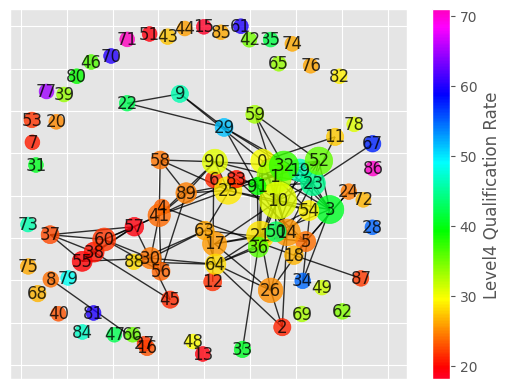

In [85]:
hsvp = cm.get_cmap("gist_rainbow")

adf = data2

cdf = pd.DataFrame(results['high_value'])

bm1 = pbm.BallMapper(X=adf, eps=15, coloring_df=cdf)

bm1.draw_networkx(coloring_variable='high_value',
                  color_palette=hsvp,
                  colorbar=True,
                  colorbar_label="Level4 Qualification Rate",
                  pos=nx.spring_layout(bm1.Graph, k=0.6, seed=4))

<Axes: >

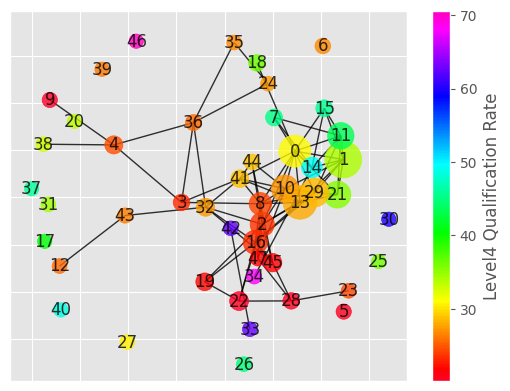

In [86]:
hsvp = cm.get_cmap("gist_rainbow")

adf = data2

cdf = pd.DataFrame(results['high_value'])

bm1 = pbm.BallMapper(X=adf, eps=20, coloring_df=cdf)

bm1.draw_networkx(coloring_variable='high_value',
                  color_palette=hsvp,
                  colorbar=True,
                  colorbar_label="Level4 Qualification Rate",
                  pos=nx.spring_layout(bm1.Graph, k=0.6, seed=4))

<Axes: >

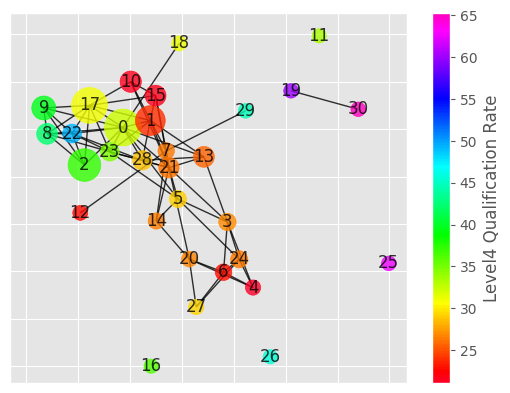

In [87]:
hsvp = cm.get_cmap("gist_rainbow")

adf = data2

cdf = pd.DataFrame(results['high_value'])

bm1 = pbm.BallMapper(X=adf, eps=25, coloring_df=cdf)

bm1.draw_networkx(coloring_variable='high_value',
                  color_palette=hsvp,
                  colorbar=True,
                  colorbar_label="Level4 Qualification Rate",
                  pos=nx.spring_layout(bm1.Graph, k=0.6, seed=4))

<Axes: >

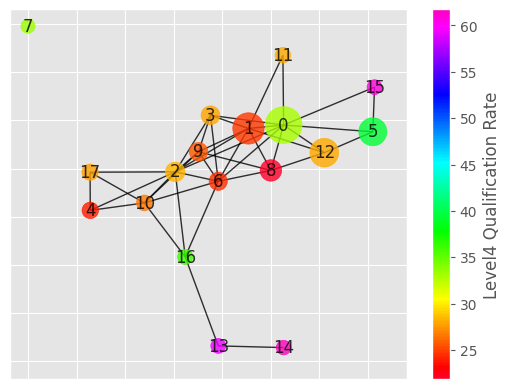

In [88]:
hsvp = cm.get_cmap("gist_rainbow")

adf = data2

cdf = pd.DataFrame(results['high_value'])

bm1 = pbm.BallMapper(X=adf, eps=30, coloring_df=cdf)

bm1.draw_networkx(coloring_variable='high_value',
                  color_palette=hsvp,
                  colorbar=True,
                  colorbar_label="Level4 Qualification Rate",
                  pos=nx.spring_layout(bm1.Graph, k=0.6, seed=4))

### for k in range(0.3, 0.9)

<Axes: >

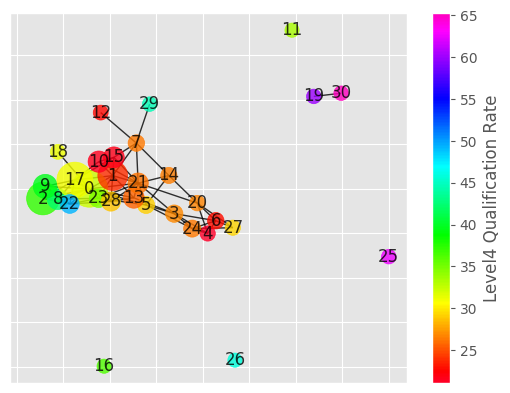

In [89]:
hsvp = cm.get_cmap("gist_rainbow")

adf = data2

cdf = pd.DataFrame(results['high_value'])

bm1 = pbm.BallMapper(X=adf, eps=25, coloring_df=cdf)

bm1.draw_networkx(coloring_variable='high_value',
                  color_palette=hsvp,
                  colorbar=True,
                  colorbar_label="Level4 Qualification Rate",
                  pos=nx.spring_layout(bm1.Graph, k=0.3, seed=4))

<Axes: >

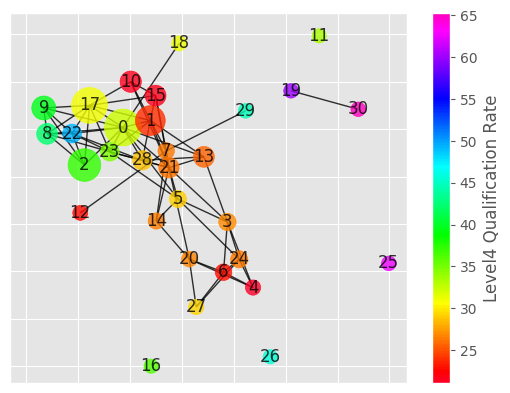

In [90]:
hsvp = cm.get_cmap("gist_rainbow")

adf = data2

cdf = pd.DataFrame(results['high_value'])

bm1 = pbm.BallMapper(X=adf, eps=25, coloring_df=cdf)

bm1.draw_networkx(coloring_variable='high_value',
                  color_palette=hsvp,
                  colorbar=True,
                  colorbar_label="Level4 Qualification Rate",
                  pos=nx.spring_layout(bm1.Graph, k=0.6, seed=4))

<Axes: >

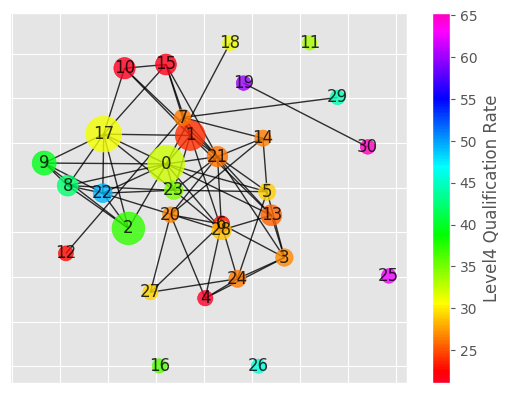

In [91]:
hsvp = cm.get_cmap("gist_rainbow")

adf = data2

cdf = pd.DataFrame(results['high_value'])

bm1 = pbm.BallMapper(X=adf, eps=25, coloring_df=cdf)

bm1.draw_networkx(coloring_variable='high_value',
                  color_palette=hsvp,
                  colorbar=True,
                  colorbar_label="Level4 Qualification Rate",
                  pos=nx.spring_layout(bm1.Graph, k=0.9, seed=4))

### seed

<Axes: >

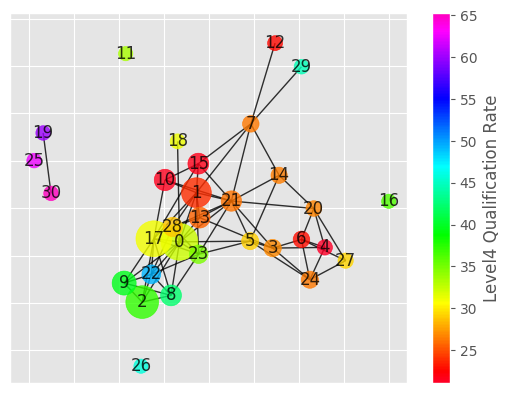

In [92]:
hsvp = cm.get_cmap("gist_rainbow")

adf = data2

cdf = pd.DataFrame(results['high_value'])

bm1 = pbm.BallMapper(X=adf, eps=25, coloring_df=cdf)

bm1.draw_networkx(coloring_variable='high_value',
                  color_palette=hsvp,
                  colorbar=True,
                  colorbar_label="Level4 Qualification Rate",
                  pos=nx.spring_layout(bm1.Graph, k=0.6, seed=1))

<Axes: >

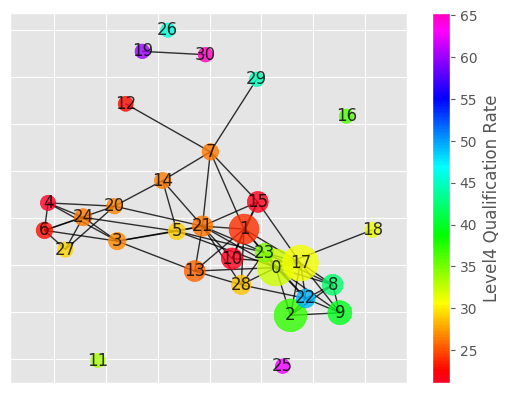

In [93]:
hsvp = cm.get_cmap("gist_rainbow")

adf = data2

cdf = pd.DataFrame(results['high_value'])

bm1 = pbm.BallMapper(X=adf, eps=25, coloring_df=cdf)

bm1.draw_networkx(coloring_variable='high_value',
                  color_palette=hsvp,
                  colorbar=True,
                  colorbar_label="Level4 Qualification Rate",
                  pos=nx.spring_layout(bm1.Graph, k=0.6, seed=2))

<Axes: >

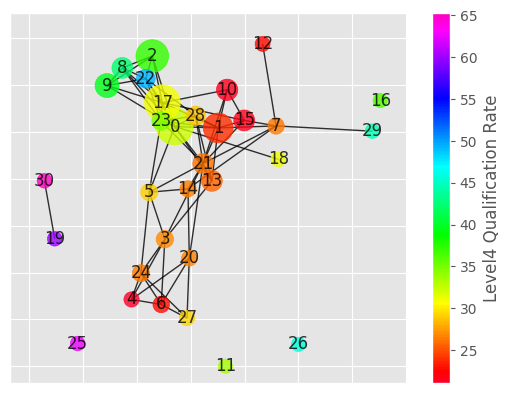

In [94]:
hsvp = cm.get_cmap("gist_rainbow")

adf = data2

cdf = pd.DataFrame(results['high_value'])

bm1 = pbm.BallMapper(X=adf, eps=25, coloring_df=cdf)

bm1.draw_networkx(coloring_variable='high_value',
                  color_palette=hsvp,
                  colorbar=True,
                  colorbar_label="Level4 Qualification Rate",
                  pos=nx.spring_layout(bm1.Graph, k=0.6, seed=3))

<Axes: >

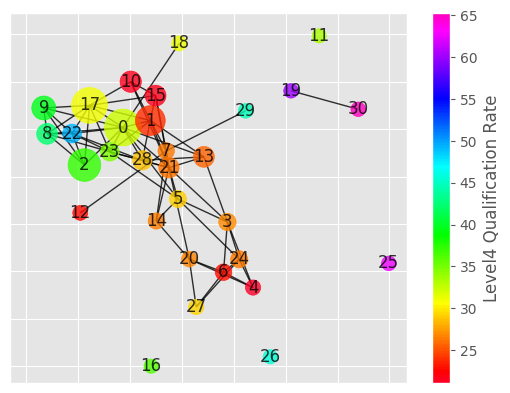

In [95]:
hsvp = cm.get_cmap("gist_rainbow")

adf = data2

cdf = pd.DataFrame(results['high_value'])

bm1 = pbm.BallMapper(X=adf, eps=25, coloring_df=cdf)

bm1.draw_networkx(coloring_variable='high_value',
                  color_palette=hsvp,
                  colorbar=True,
                  colorbar_label="Level4 Qualification Rate",
                  pos=nx.spring_layout(bm1.Graph, k=0.6, seed=4))

<Axes: >

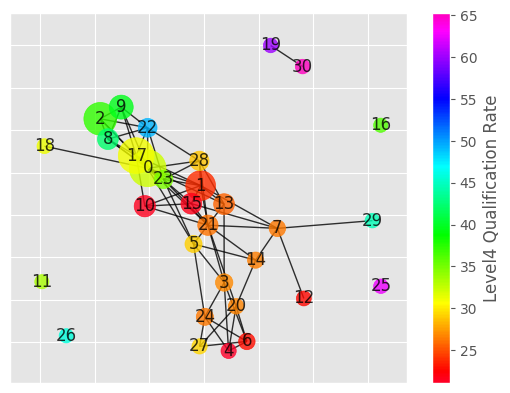

In [96]:
hsvp = cm.get_cmap("gist_rainbow")

adf = data2

cdf = pd.DataFrame(results['high_value'])

bm1 = pbm.BallMapper(X=adf, eps=25, coloring_df=cdf)

bm1.draw_networkx(coloring_variable='high_value',
                  color_palette=hsvp,
                  colorbar=True,
                  colorbar_label="Level4 Qualification Rate",
                  pos=nx.spring_layout(bm1.Graph, k=0.6, seed=5))

<Axes: >

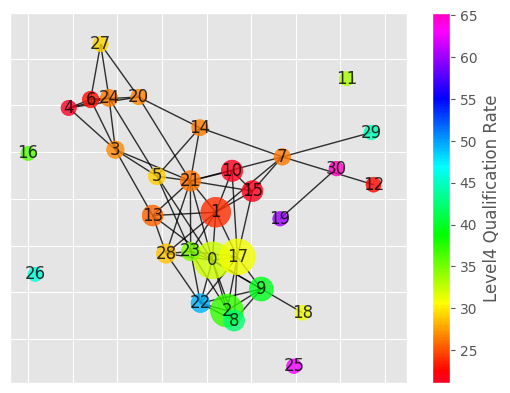

In [97]:
hsvp = cm.get_cmap("gist_rainbow")

adf = data2

cdf = pd.DataFrame(results['high_value'])

bm1 = pbm.BallMapper(X=adf, eps=25, coloring_df=cdf)

bm1.draw_networkx(coloring_variable='high_value',
                  color_palette=hsvp,
                  colorbar=True,
                  colorbar_label="Level4 Qualification Rate",
                  pos=nx.spring_layout(bm1.Graph, k=0.6, seed=6))

## <3.2. Different dataset>
<br> data3 -> all variables

In [98]:
results

,Ward_Code,WD22NM,WD22NMW,LAD22CD,LAD22NM,BNG_E,BNG_N,LONG,LAT,GlobalID,...,adult_ratio,old_ratio,youthp,adultp,oldp,prediction1,residual1,highly_educated,manage_nssec,point
0,E05000650,Astley Bridge,None,E08000001,Bolton,370670,412906,-2.44479,53.6119,fb9555e0-fe42-4ed7-9525-83d2ef94b123,...,0.611995,0.193932,19.407313,61.199519,19.393168,32.005980,-1.305980,0,46.4,0
1,E05000651,Bradshaw,None,E08000001,Bolton,374590,413058,-2.38555,53.6135,25dbefbc-459d-4966-b69b-61e110806f46,...,0.547260,0.272286,18.045439,54.725980,27.228581,31.011924,1.488076,1,50.8,1
2,E05000652,Breightmet,None,E08000001,Bolton,374437,409641,-2.38758,53.5827,8fa89cd8-e6ac-4a50-90bd-cc5a5fd83f3a,...,0.595208,0.183819,22.097222,59.520833,18.381944,18.937068,1.262932,0,32.9,2
3,E05000653,Bromley Cross,None,E08000001,Bolton,372113,414150,-2.42309,53.6231,3ca0e3ab-5ae6-4699-9438-fea1e93d2fc3,...,0.597506,0.234250,16.824349,59.750642,23.425009,39.135030,0.664970,1,58.0,3
4,E05000654,Crompton,None,E08000001,Bolton,371741,410493,-2.42838,53.5903,538db093-64e4-4ffd-b942-db4d2401f099,...,0.648789,0.109658,24.155386,64.878853,10.965760,26.379227,-2.279227,0,31.4,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
292,E05014164,Redvales,None,E08000002,Bury,380425,409708,-2.29714,53.5836,d4aaae14-49e2-4ac6-b15c-77bd448ed9e3,...,0.635029,0.139041,22.593035,63.502902,13.904063,25.675509,1.224491,0,34.3,292
293,E05014165,Sedgley,None,E08000002,Bury,382543,403008,-2.26477,53.5235,b1049fe0-6595-467e-a72e-cd43c76988b7,...,0.567854,0.134224,29.792131,56.785449,13.422420,36.282402,1.217598,1,50.5,293
294,E05014166,St. Mary's,None,E08000002,Bury,380192,403381,-2.30026,53.5267,9d974996-37be-4d2c-9168-02b3aeeebecf,...,0.648258,0.174719,17.702331,64.825813,17.471855,42.349867,-0.549867,1,52.6,294
295,E05014167,Tottington,None,E08000002,Bury,376833,412710,-2.35162,53.6104,e860c4dd-25a0-4827-b42c-58fb85938eed,...,0.611139,0.219597,16.926437,61.113869,21.959694,33.794610,-0.494610,1,52.7,295


In [99]:
data3 = results[['goodhealthp',
                 'disabledp',
                 'Deprived0p', 'Deprived1p', 'Deprived24p',
                 'tenureownp', 'socrentp', 'privrentp',
                 'employeep', 'selfemployeep', 'nonemployedp',
                 'ethnwhitep', 'ethnotherp',
                 'nssec1', 'nssec2', 'nssec3', 'nssec4', 'nssec5',
                 'popdensity',
                 'nocarp', '1carp', '23carp',
                 'lowhousingp', 'midhousingp', 'highhousingp',
                 'youthp', 'oldp',
                 'numberofschools']]
data3

,goodhealthp,disabledp,Deprived0p,Deprived1p,Deprived24p,tenureownp,socrentp,privrentp,employeep,selfemployeep,...,popdensity,nocarp,1carp,23carp,lowhousingp,midhousingp,highhousingp,youthp,oldp,numberofschools
0,82.2,82.7,49.6,33.4,17.0,71.4,13.7,14.6,46.3,9.1,...,14.986014,20.2,42.0,37.9,38.9,57.6,3.6,19.407313,19.393168,4.0
1,80.8,81.4,50.5,33.6,15.9,78.7,13.4,7.6,41.6,8.2,...,7.922402,16.1,41.3,42.6,23.4,71.1,5.6,18.045439,27.228581,4.0
2,76.7,77.2,36.5,35.2,28.3,54.4,34.4,10.7,43.2,6.4,...,28.637092,30.0,41.9,28.2,40.6,58.0,1.3,22.097222,18.381944,13.0
3,85.5,85.0,58.4,31.0,10.6,82.4,4.4,12.8,48.0,9.6,...,13.514363,11.5,41.5,47.0,30.0,62.7,7.3,16.824349,23.425009,4.0
4,81.2,83.0,37.4,34.5,28.1,48.4,24.9,26.0,44.0,7.2,...,37.665001,31.6,45.4,23.0,55.9,42.2,1.9,24.155386,10.965760,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
292,78.9,81.2,38.6,35.6,25.8,54.1,24.7,20.6,43.5,8.0,...,27.923660,28.1,45.1,26.8,45.4,51.7,2.8,22.593035,13.904063,9.0
293,85.3,84.8,49.7,33.3,17.0,67.8,10.0,21.8,47.6,11.1,...,49.823213,19.9,46.5,33.6,21.7,68.7,9.5,29.792131,13.422420,9.0
294,80.8,80.0,50.5,31.7,17.8,64.9,17.7,17.1,49.2,9.0,...,15.692375,23.2,45.6,31.1,33.7,60.5,5.8,17.702331,17.471855,5.0
295,82.6,81.9,55.1,32.4,12.4,82.7,4.5,12.5,49.4,9.2,...,7.512257,12.2,41.7,46.1,30.7,64.2,5.1,16.926437,21.959694,4.0


<Axes: >

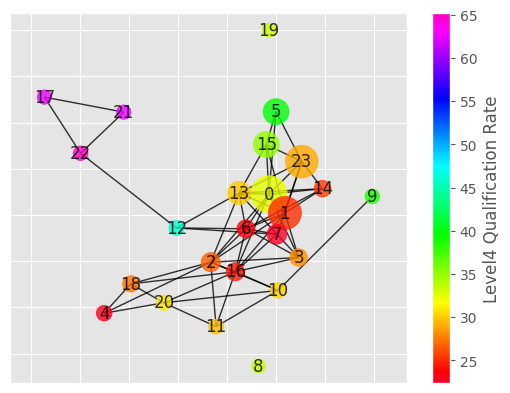

In [113]:
hsvp = cm.get_cmap("gist_rainbow")

adf = data3

cdf = pd.DataFrame(results['high_value'])

bm1 = pbm.BallMapper(X=adf, eps=45, coloring_df=cdf)

bm1.draw_networkx(coloring_variable='high_value',
                  color_palette=hsvp,
                  colorbar=True,
                  colorbar_label="Level4 Qualification Rate",
                  pos=nx.spring_layout(bm1.Graph, k=0.7, seed=5))

In [114]:
pb1 = bm1.points_and_balls()

fulld = data.merge(pb1, on='point')
subd = results.merge(pb1, on='point')

ballslist2 = pd.DataFrame(subd[["ball","Ward_Code","WD22NM",'high_value', 'goodhealthp',
                 'disabledp',
                 'Deprived0p', 'Deprived1p', 'Deprived24p',
                 'tenureownp', 'socrentp', 'privrentp',
                 'employeep', 'selfemployeep', 'nonemployedp',
                 'ethnwhitep', 'ethnotherp',
                 'nssec1', 'nssec2', 'nssec3', 'nssec4', 'nssec5',
                 'popdensity',
                 'nocarp', '1carp', '23carp',
                 'lowhousingp', 'midhousingp', 'highhousingp',
                 'youthp', 'oldp',
                 'numberofschools']])

shape3 = shape.merge(results[['Ward_Code','high_value', 'goodhealthp',
                 'disabledp',
                 'Deprived0p', 'Deprived1p', 'Deprived24p',
                 'tenureownp', 'socrentp', 'privrentp',
                 'employeep', 'selfemployeep', 'nonemployedp',
                 'ethnwhitep', 'ethnotherp',
                 'nssec1', 'nssec2', 'nssec3', 'nssec4', 'nssec5',
                 'popdensity',
                 'nocarp', '1carp', '23carp',
                 'lowhousingp', 'midhousingp', 'highhousingp',
                 'youthp', 'oldp',
                 'numberofschools']], on='Ward_Code', how='left')

ballslist2 = ballslist2.drop_duplicates(subset=['Ward_Code'])
ballslist2.sort_values('ball', ascending=True)

,ball,Ward_Code,WD22NM,high_value,goodhealthp,disabledp,Deprived0p,Deprived1p,Deprived24p,tenureownp,...,popdensity,nocarp,1carp,23carp,lowhousingp,midhousingp,highhousingp,youthp,oldp,numberofschools
0,0,E05000650,Astley Bridge,30.7,82.2,82.7,49.6,33.4,17.0,71.4,...,14.986014,20.2,42.0,37.9,38.9,57.6,3.6,19.407313,19.393168,4.0
1,0,E05000651,Bradshaw,32.5,80.8,81.4,50.5,33.6,15.9,78.7,...,7.922402,16.1,41.3,42.6,23.4,71.1,5.6,18.045439,27.228581,4.0
710,0,E05014168,Unsworth,31.8,80.9,81.9,49.6,33.1,17.3,74.7,...,7.189327,17.9,44.0,38.2,26.2,70.6,3.4,17.727602,21.536090,10.0
5,0,E05000653,Bromley Cross,39.8,85.5,85.0,58.4,31.0,10.6,82.4,...,13.514363,11.5,41.5,47.0,30.0,62.7,7.3,16.824349,23.425009,4.0
707,0,E05014167,Tottington,33.3,82.6,81.9,55.1,32.4,12.4,82.7,...,7.512257,12.2,41.7,46.1,30.7,64.2,5.1,16.926437,21.959694,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499,19,E05011372,Moss Side,33.1,84.3,85.4,35.1,36.4,28.5,20.8,...,100.000000,50.3,38.8,10.9,40.3,57.3,2.5,25.364363,6.093089,11.0
509,20,E05011377,Rusholme,30.9,84.0,83.9,36.7,36.8,26.5,31.3,...,61.835282,44.1,36.8,19.1,41.1,51.4,7.4,15.554918,6.148552,11.0
520,21,E05013019,Blackfriars & Trinity,60.0,89.1,86.9,58.3,28.8,12.8,17.8,...,80.879534,56.7,35.8,7.5,84.5,15.4,0.0,6.892019,2.507042,2.0
546,22,E05013031,Quays,70.5,90.7,89.6,64.1,28.4,7.5,15.4,...,36.887139,45.6,43.0,11.3,88.6,11.4,0.0,5.151092,2.645446,4.0


In [115]:
ballslist2.groupby('ball')[['high_value', 'goodhealthp',
                 'disabledp',
                 'Deprived0p', 'Deprived1p', 'Deprived24p',
                 'tenureownp', 'socrentp', 'privrentp',
                 'employeep', 'selfemployeep', 'nonemployedp',
                 'ethnwhitep', 'ethnotherp',
                 'nssec1', 'nssec2', 'nssec3', 'nssec4', 'nssec5',
                 'popdensity',
                 'nocarp', '1carp', '23carp',
                 'lowhousingp', 'midhousingp', 'highhousingp',
                 'youthp', 'oldp',
                 'numberofschools']].mean().sort_index(ascending=True)


,high_value,goodhealthp,disabledp,Deprived0p,Deprived1p,Deprived24p,tenureownp,socrentp,privrentp,employeep,...,popdensity,nocarp,1carp,23carp,lowhousingp,midhousingp,highhousingp,youthp,oldp,numberofschools
ball,,,,,,,,,,,,,,,,,,,,,
0,32.363333,80.861333,80.952000,48.517333,32.930667,18.553333,68.460000,14.981333,15.870667,48.193333,...,19.104558,21.332667,43.664667,35.009333,31.402667,64.253333,4.339333,18.813341,19.604421,5.653333
1,22.726531,76.300000,76.246939,37.414286,33.718367,28.871429,48.712245,31.663265,18.602041,45.691837,...,27.709944,35.620408,42.381633,22.010204,31.046939,67.089796,1.857143,21.067952,15.679019,9.857143
2,27.361111,80.016667,82.116667,35.566667,35.072222,29.366667,42.866667,28.266667,27.961111,40.500000,...,37.503536,37.133333,42.427778,20.422222,48.650000,48.950000,2.411111,25.083549,10.662576,9.166667
3,28.050000,80.900000,82.200000,37.450000,35.800000,26.700000,53.450000,30.550000,14.700000,41.650000,...,45.964548,26.550000,44.850000,28.550000,22.800000,75.700000,1.600000,25.815962,12.103859,8.000000
4,23.150000,80.583333,84.300000,28.416667,36.466667,35.100000,41.350000,29.800000,27.766667,34.566667,...,54.730158,37.933333,41.466667,20.583333,49.950000,46.350000,3.666667,28.155030,8.156883,7.500000
5,41.041667,83.525000,82.950000,56.075000,31.725000,12.204167,84.558333,5.383333,9.641667,44.362500,...,10.247606,12.712500,40.500000,46.779167,15.112500,75.100000,9.775000,16.961155,26.516472,6.875000
6,25.250000,74.837500,74.925000,34.087500,33.175000,32.737500,28.425000,43.112500,27.087500,40.737500,...,28.057625,50.175000,38.150000,11.675000,47.850000,50.650000,1.512500,19.469440,12.501517,15.375000
7,22.333333,75.516667,75.166667,35.483333,33.816667,30.666667,44.600000,27.316667,27.616667,43.666667,...,50.564277,43.466667,40.000000,16.566667,22.283333,74.883333,2.850000,20.314158,15.352992,8.500000
8,33.400000,89.000000,86.300000,53.100000,32.200000,14.700000,17.400000,15.200000,66.900000,22.400000,...,58.558049,63.000000,30.300000,6.700000,72.400000,24.000000,3.700000,3.589826,3.247746,6.000000


In [129]:
# Purple - High
subset6 = ballslist2[ballslist2['ball'].isin([17,21,22,12])]
subset6

,ball,Ward_Code,WD22NM,high_value,goodhealthp,disabledp,Deprived0p,Deprived1p,Deprived24p,tenureownp,...,popdensity,nocarp,1carp,23carp,lowhousingp,midhousingp,highhousingp,youthp,oldp,numberofschools
303,12,E05000907,Riverside,42.3,80.4,79.9,44.9,33.3,21.8,22.2,...,46.237979,52.0,38.4,9.6,65.0,33.4,1.6,11.369453,10.510563,14.0
459,12,E05011350,Ancoats & Beswick,60.0,86.2,85.3,59.3,26.3,14.4,25.4,...,37.769502,47.4,43.0,9.6,73.3,26.1,0.5,12.238564,5.727972,16.0
481,17,E05011361,Deansgate,60.2,93.2,89.8,70.3,24.7,5.0,22.9,...,52.439657,60.7,33.8,5.6,94.8,5.0,0.3,2.322863,1.804237,4.0
493,12,E05011368,Hulme,45.9,87.2,85.0,52.1,30.3,17.6,18.7,...,55.298887,52.5,40.3,7.1,74.5,25.0,0.4,11.382656,3.609385,20.0
506,17,E05011376,Piccadilly,65.0,90.7,88.5,63.3,27.7,9.0,19.5,...,45.511974,68.1,27.6,4.3,92.6,7.1,0.3,2.454093,2.548481,6.0
520,21,E05013019,Blackfriars & Trinity,60.0,89.1,86.9,58.3,28.8,12.8,17.8,...,80.879534,56.7,35.8,7.5,84.5,15.4,0.0,6.892019,2.507042,2.0
540,12,E05013028,Ordsall,47.0,83.4,83.3,50.5,28.8,20.7,19.4,...,37.428500,49.3,41.1,9.6,68.5,31.0,0.6,14.097353,7.792208,4.0
546,22,E05013031,Quays,70.5,90.7,89.6,64.1,28.4,7.5,15.4,...,36.887139,45.6,43.0,11.3,88.6,11.4,0.0,5.151092,2.645446,4.0


In [130]:
subset7 = ballslist2[ballslist2['ball'].isin([6,7,16,4])]
subset7

,ball,Ward_Code,WD22NM,high_value,goodhealthp,disabledp,Deprived0p,Deprived1p,Deprived24p,tenureownp,...,popdensity,nocarp,1carp,23carp,lowhousingp,midhousingp,highhousingp,youthp,oldp,numberofschools
34,4,E05000665,Rumworth,20.8,81.4,84.9,26.5,37.8,35.7,44.3,...,71.888554,36.2,44.8,19.1,57.5,39.6,2.8,27.352974,9.582920,3.0
56,4,E05000723,Coldhurst,18.1,78.5,83.5,23.5,35.7,40.8,36.3,...,40.949305,46.6,37.1,16.3,54.2,43.0,2.9,29.255468,8.125351,7.0
92,4,E05000735,St Mary's,19.3,80.4,84.0,25.1,37.9,37.0,44.8,...,44.910114,36.2,41.3,22.4,47.4,48.4,4.2,29.896535,7.663619,7.0
100,4,E05000738,Werneth,22.5,80.9,85.1,29.4,35.8,34.7,50.6,...,68.568892,31.0,41.3,27.7,41.3,51.9,6.7,29.462540,8.496864,8.0
110,6,E05000783,Brinnington and Central,25.1,73.7,73.3,34.4,33.3,32.3,28.6,...,23.673707,46.7,38.9,14.4,61.7,37.5,0.8,21.343409,11.777218,12.0
268,7,E05000887,Anfield,21.1,75.9,76.0,34.5,34.5,30.9,39.8,...,47.722987,49.7,38.2,12.1,23.3,73.7,3.0,19.524779,14.392396,7.0
276,7,E05000892,Clubmoor,19.1,73.9,73.5,31.9,34.4,33.7,47.0,...,42.086240,40.4,41.2,18.4,12.9,86.6,0.6,20.387373,16.966419,12.0
277,7,E05000893,County,20.8,73.9,73.8,32.9,33.7,33.4,39.3,...,53.651235,53.7,35.7,10.7,27.1,69.8,3.1,19.621240,15.514296,8.0
284,6,E05000896,Everton,22.9,70.8,72.3,28.8,32.7,38.6,25.1,...,36.392922,55.6,35.0,9.4,46.3,52.5,1.2,18.440204,15.689645,27.0
289,6,E05000900,Kirkdale,25.8,74.0,75.1,34.7,32.2,33.2,27.6,...,22.159627,53.6,37.1,9.4,44.8,54.3,0.9,16.432629,14.996248,26.0


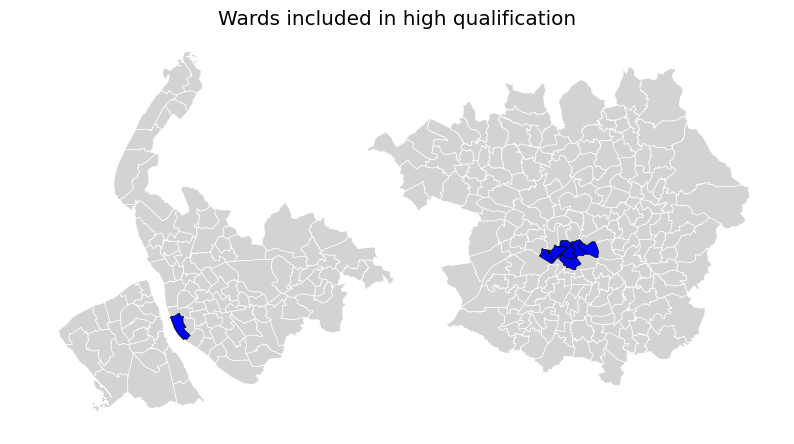

In [131]:
shape2 = shape2.merge(ballslist2[['Ward_Code', 'high_value', 'goodhealthp',
                 'disabledp',
                 'Deprived0p', 'Deprived1p', 'Deprived24p',
                 'tenureownp', 'socrentp', 'privrentp',
                 'employeep', 'selfemployeep', 'nonemployedp',
                 'ethnwhitep', 'ethnotherp',
                 'nssec1', 'nssec2', 'nssec3', 'nssec4', 'nssec5',
                 'popdensity',
                 'nocarp', '1carp', '23carp',
                 'lowhousingp', 'midhousingp', 'highhousingp',
                 'youthp', 'oldp',
                 'numberofschools']],
                      on='Ward_Code', how='inner')

wards6 = subset6['Ward_Code'].unique()

all_wards_high = wards6

highlight_shape = shape[shape['Ward_Code'].isin(all_wards_high)]

fig, ax = plt.subplots(figsize=(10, 10))
shape2.plot(ax=ax, color='lightgrey', edgecolor='white')
highlight_shape.plot(ax=ax, color='blue', edgecolor='black')

plt.title("Wards included in high qualification")
plt.axis('off')
plt.show()


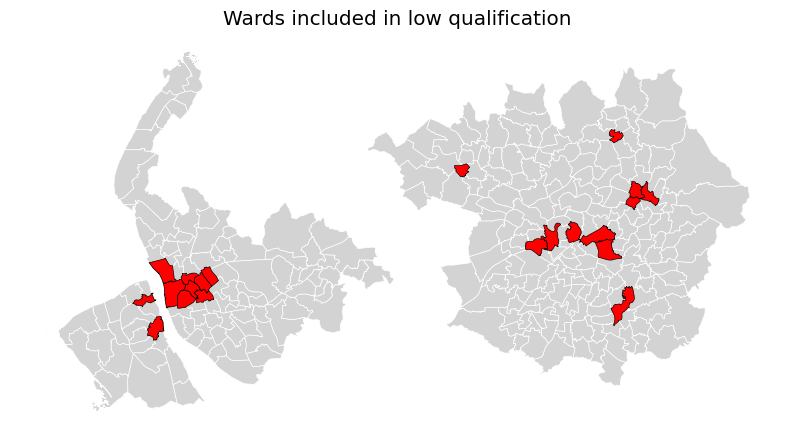

In [132]:
wards7 = subset7['Ward_Code'].unique()

all_wards_high = wards7

highlight_shape = shape[shape['Ward_Code'].isin(all_wards_high)]

fig, ax = plt.subplots(figsize=(10, 10))
shape2.plot(ax=ax, color='lightgrey', edgecolor='white')
highlight_shape.plot(ax=ax, color='red', edgecolor='black')

plt.title("Wards included in low qualification")
plt.axis('off')
plt.show()


In [ ]:
# Can we combine the major Universities's location (using coordinate info) and present on the map?
# Any method that visualize the inequality?